# 🤖 Transformers From Scratch — Attention, Mini-GPT, and the KV Cache

> **What you'll learn:** how text becomes tokens (including byte-pair encoding built by hand), how self-attention works line by line, why we divide by √d_k, masks, multi-head attention, positional encodings and RoPE, the transformer block, parameter counting, the O(n²) cost, sampling, and the KV cache — then you train a small GPT on real Shakespeare text on your laptop.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [PyTorch](02_PyTorch.ipynb) (tensors, `nn.Module`, training loops) · helpful: [Neural Networks From Scratch](01_Neural_Networks_From_Scratch.ipynb) |
| **Tested with** | Python 3.12 · torch 2.14 (Apple MPS, CUDA, or CPU) · tiktoken 0.14 and transformers 5 (optional comparisons) |
| **Interview relevance** | ⭐⭐⭐ Very high — "walk me through self-attention", "why √d_k?", "implement causal attention", "what is a KV cache and how big is it?", "how do long-context models work?" |

## 🤔 What Is a Transformer?

A **transformer** is a neural network that reads a whole sequence at once and lets **every token look at every other token** to decide what matters. That "looking" is called **attention**.

Everyday analogy — a meeting where everyone speaks at once, politely:

- Each word writes a **question** on a card: *"I'm the word 'it' — who am I referring to?"* → the **query**
- Each word wears a **name tag** describing what it offers: *"I'm 'the cat', a noun, the subject"* → the **key**
- Each word also holds the **information** it will share if asked → the **value**

Every word compares its question with every name tag, pays more attention to the best matches, and collects a weighted mix of their information. Stack this dozens of times and you get GPT, Llama, BERT, and Whisper.

```
tokens ─► embeddings ─► [ attention → MLP ] × N layers ─► scores for the next token
                           ▲ every token looks at the others here
```

A **GPT** (Generative Pre-trained Transformer) is a transformer trained to predict the **next token** — and that single skill, scaled up, is what powers modern large language models (LLMs).

## 🎯 Why It Matters

- **Every LLM is a transformer.** GPT, Llama, Mistral, Qwen, Gemma, BERT, T5, and Whisper are all variations of the block you build here.
- **Real engineering decisions depend on it:** context length vs memory (KV cache), latency (O(n²) attention), sampling settings (temperature/top-p), tokenizer choice (cost per request), and model size (parameter counts).
- **In interviews** for AI/ML engineer roles in 2025–2026 you will very likely be asked to *explain* self-attention step by step, *code* causal attention in PyTorch, *derive* the KV-cache memory formula, and *discuss* long-context techniques like FlashAttention and grouped-query attention. This notebook practises each of those.

## ✅ By the End You Can

- [ ] Explain why attention replaced RNNs, and train a byte-pair-encoding tokenizer from scratch
- [ ] Implement scaled dot-product attention with causal and padding masks, and prove it matches `F.scaled_dot_product_attention`
- [ ] Build multi-head attention, sinusoidal encodings, RoPE, and a pre-LayerNorm transformer block — stating the tensor shape at every step
- [ ] Count a transformer's parameters by formula and measure attention's O(n²) cost
- [ ] Implement greedy, temperature, top-k and top-p sampling plus a KV cache, and compute KV-cache memory for a real model
- [ ] Train a small GPT on real text, report validation/test loss against baselines, and generate samples

## 📋 Table of Contents

1. [Why Attention? The RNN Bottleneck](#1.-Why-Attention?-The-RNN-Bottleneck-🟢)
2. [Tokenization I: Characters](#2.-Tokenization-I:-Characters-🟢)
3. [Tokenization II: Byte-Pair Encoding From Scratch](#3.-Tokenization-II:-Byte-Pair-Encoding-From-Scratch-🟡)
4. [Token Embeddings](#4.-Token-Embeddings-🟢)
5. [Scaled Dot-Product Attention](#5.-Scaled-Dot-Product-Attention-🟡)
6. [Padding and Causal Masks](#6.-Padding-and-Causal-Masks-🟡)
7. [Multi-Head Attention](#7.-Multi-Head-Attention-🟡)
8. [Positional Information: Sinusoidal and RoPE](#8.-Positional-Information:-Sinusoidal-and-RoPE-🔴)
9. [The Transformer Block: LayerNorm, Residuals, MLP](#9.-The-Transformer-Block:-LayerNorm,-Residuals,-MLP-🟡)
10. [Encoder, Decoder, and Encoder–Decoder](#10.-Encoder,-Decoder,-and-Encoder–Decoder-🟢)
11. [Assembling a Mini GPT and Counting Parameters](#11.-Assembling-a-Mini-GPT-and-Counting-Parameters-🟡)
12. [The O(n²) Cost of Attention](#12.-The-O(n²)-Cost-of-Attention-🔴)
13. [Sampling: Greedy, Temperature, Top-k, Top-p](#13.-Sampling:-Greedy,-Temperature,-Top-k,-Top-p-🟡)
14. [Generation and the KV Cache](#14.-Generation-and-the-KV-Cache-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Train-a-Character-Level-GPT-on-Shakespeare) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. It picks the fastest device available (Apple **MPS**, NVIDIA **CUDA**, or **CPU**) and downloads the tiny Shakespeare text (~1 MB) used throughout.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). It accepts tensors, lists, and numbers.

In [1]:
# %pip install -q "torch>=2.5" numpy matplotlib "tiktoken>=0.7" "transformers>=4.45"

import copy
import math
import sys
import time
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | device: {DEVICE}")

torch.manual_seed(42)
OUTPUT_DIR = Path("_outputs")                  # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def sync():
    """GPU work is asynchronous — wait for it to finish before reading a timer."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


def check(name, got, expected, hint="", atol=1e-4):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def to_np(v):
        return v.detach().cpu().numpy() if torch.is_tensor(v) else np.asarray(v)

    got_arr, exp_arr = to_np(got), to_np(expected)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
    if numeric:
        ok = np.allclose(got_arr.astype(np.float64), exp_arr.astype(np.float64), atol=atol)
    else:
        ok = np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | device: mps


## 1. Why Attention? The RNN Bottleneck 🟢

Before transformers (2017), text models were mostly **RNNs** (recurrent neural networks): they read one token at a time and squeeze everything seen so far into one fixed-size **hidden state** vector.

```
RNN:        x1 → [h1] → [h2] → [h3] → ... → [h100] → prediction        (information hops 99 times)
Attention:  x1 ─────────────────────────────────► x100                  (one direct hop)
```

That design has two problems:
1. **Bottleneck and vanishing gradients** — information about token 1 must survive 99 squeezes to reach token 100, and the gradient that trains it shrinks at every hop.
2. **No parallelism over time** — step 50 can't start until step 49 is done, so GPUs sit idle.

Attention fixes both: every token connects **directly** to every other token in one matrix multiplication. Let's *measure* problem 1: how strongly does the last output depend on each input position?

In [2]:
torch.manual_seed(0)
seq_len, dim = 100, 32

rnn = nn.RNN(input_size=dim, hidden_size=64, batch_first=True)    # classic tanh RNN
x_rnn = torch.randn(1, seq_len, dim, requires_grad=True)
rnn_out, _ = rnn(x_rnn)
rnn_out[0, -1].sum().backward()                                    # gradient of the LAST output...
rnn_grad = x_rnn.grad[0].norm(dim=-1)                              # ...w.r.t. every input position

x_att = torch.randn(1, seq_len, dim, requires_grad=True)
W_q, W_k, W_v = (nn.Linear(dim, dim) for _ in range(3))
scores = W_q(x_att) @ W_k(x_att).transpose(-2, -1) / math.sqrt(dim)
att_out = torch.softmax(scores, dim=-1) @ W_v(x_att)               # one self-attention layer
att_out[0, -1].sum().backward()
att_grad = x_att.grad[0].norm(dim=-1)

for name, g in [("RNN", rnn_grad), ("Attention", att_grad)]:
    print(f"{name:9s} gradient reaching position 0: {g[0]:.1e} | position 50: {g[50]:.1e} | position 99: {g[99]:.1e}")

rnn_ratio = (rnn_grad[0] / rnn_grad[-1]).item()
att_ratio = (att_grad[0] / att_grad[-1]).item()
print(f"\nfirst-vs-last gradient ratio → RNN {rnn_ratio:.1e}, attention {att_ratio:.1e}")
if rnn_ratio < 1e-6 < att_ratio:
    print("→ in the RNN the first token's signal has vanished; attention still connects it directly.")

RNN       gradient reaching position 0: 0.0e+00 | position 50: 5.7e-16 | position 99: 3.4e+00
Attention gradient reaching position 0: 4.1e-02 | position 50: 3.1e-02 | position 99: 1.4e-01

first-vs-last gradient ratio → RNN 0.0e+00, attention 2.9e-01
→ in the RNN the first token's signal has vanished; attention still connects it directly.


> 💡 **Interview angle:** "Why did transformers replace RNNs?" — (1) **path length**: any two tokens are one attention hop apart, so long-range gradients don't vanish; (2) **parallel training**: all positions are processed at once instead of step by step. The price is O(n²) attention cost (Section 12).

## 2. Tokenization I: Characters 🟢

Neural networks eat numbers, not text. A **tokenizer** splits text into **tokens** and maps each to an integer **id**. The set of possible tokens is the **vocabulary**.

The simplest tokenizer uses **characters**: every distinct character in the text gets an id. Let's load the real dataset — [tiny Shakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt), ~1.1 million characters of Shakespeare's plays collected by Andrej Karpathy.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = OUTPUT_DIR / "tinyshakespeare.txt"
if not data_path.exists():
    urllib.request.urlretrieve(DATA_URL, data_path)            # ~1.1 MB, downloaded once
text = data_path.read_text(encoding="utf-8")

print(f"{len(text):,} characters | {len(text.split()):,} words")
print("-" * 40)
print(text[:250])

1,115,394 characters | 202,651 words
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}                   # string → id
itos = {i: ch for ch, i in stoi.items()}                       # id → string


def encode_chars(s):
    return [stoi[c] for c in s]


def decode_chars(ids):
    return "".join(itos[i] for i in ids)


print(f"vocabulary size: {vocab_size}")
print("vocabulary:", repr("".join(chars)))
ids = encode_chars("To be, or not to be")
print("encoded:", ids)
print("decoded:", decode_chars(ids))
assert decode_chars(encode_chars(text[:5000])) == text[:5000]   # lossless round trip

data = torch.tensor(encode_chars(text), dtype=torch.long)       # the whole corpus as ids
print("corpus tensor:", data.shape, data.dtype)

vocabulary size: 65
vocabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
encoded: [32, 53, 1, 40, 43, 6, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43]
decoded: To be, or not to be
corpus tensor: torch.Size([1115394]) torch.int64


### ✍️ Your Turn

Build the **sorted character vocabulary** (a list of unique characters) for the word `"mississippi"`.

In [5]:
word = "mississippi"
word_vocab = None  # TODO: your code here
check("word_vocab", word_vocab, ["i", "m", "p", "s"], hint="set() removes duplicates; sorted() returns a sorted list.")

⏳ word_vocab: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
word = "mississippi"
word_vocab = sorted(set(word))
check("word_vocab", word_vocab, ["i", "m", "p", "s"])
```
</details>

> 💡 **Interview angle:** "Why don't LLMs use characters or whole words?" — characters make sequences very long (attention cost grows with length); whole words make the vocabulary huge and can't handle new words. **Subword** tokenizers like BPE sit in between.

## 3. Tokenization II: Byte-Pair Encoding From Scratch 🟡

**Byte-pair encoding (BPE)** builds a vocabulary of *subwords* by **repeatedly merging the most frequent neighbouring pair** of tokens:

```
start (bytes):  t h e ␣ t h e r e       most frequent pair: (t, h) → new token 256 "th"
after merge 1:  th e ␣ th e r e         most frequent pair: (th, e) → new token 257 "the"
after merge 2:  the ␣ the r e           ... repeat for N merges
```

Modern LLM tokenizers (GPT-2, GPT-4, Llama 3) use **byte-level BPE**: start from the 256 possible **bytes** of UTF-8 text, so *any* string — emoji, accents, code — can be encoded without an "unknown" token.

We implement the three pieces: count pairs, merge a pair, and train.

In [6]:
def get_pair_counts(ids):
    """Count how often each adjacent pair appears: [1, 2, 1, 2] → {(1, 2): 2, (2, 1): 1}."""
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts


def merge_pair(ids, pair, new_id):
    """Replace every non-overlapping occurrence of `pair` (left to right) with `new_id`."""
    out, i = [], 0
    while i < len(ids):
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
            out.append(new_id)
            i += 2
        else:
            out.append(ids[i])
            i += 1
    return out


def train_bpe(training_text, n_merges):
    ids = list(training_text.encode("utf-8"))                   # start from raw bytes (0..255)
    merges = {}                                                 # (id_a, id_b) → new id, in creation order
    vocab = {i: bytes([i]) for i in range(256)}                 # id → the bytes it stands for
    for step in range(n_merges):
        counts = get_pair_counts(ids)
        best = max(counts, key=counts.get)
        new_id = 256 + step
        ids = merge_pair(ids, best, new_id)
        merges[best] = new_id
        vocab[new_id] = vocab[best[0]] + vocab[best[1]]
    return merges, vocab


print(get_pair_counts([1, 2, 1, 2]))
print(merge_pair([1, 2, 3, 1, 2], (1, 2), 99))

{(1, 2): 2, (2, 1): 1}
[99, 3, 99]


In [7]:
n_train_chars = int(0.8 * len(text))                            # only learn from the training part of the corpus
start = time.perf_counter()
bpe_merges, bpe_vocab = train_bpe(text[:100_000], n_merges=256)
print(f"trained 256 merges on 100k characters in {time.perf_counter() - start:.1f} s → vocabulary of {len(bpe_vocab)} tokens")
print("first 10 merges :", [bpe_vocab[256 + i].decode("utf-8", errors="replace") for i in range(10)])
print("last 10 merges  :", [bpe_vocab[502 + i].decode("utf-8", errors="replace") for i in range(10)])

trained 256 merges on 100k characters in 2.0 s → vocabulary of 512 tokens
first 10 merges : ['e ', 'th', 't ', 's ', 'ou', ', ', 'd ', 'er', 'an', 'in']
last 10 merges  : ['.\n\nV', 'fe', '! ', 'good ', ' them', 'with ', 'shall ', '\nH', '\nThe ', 'el']


To **encode** new text, apply the learned merges **in the order they were learned** (lowest new id first). To **decode**, look up each id's bytes and join them.

In [8]:
def bpe_encode(s, merges):
    ids = list(s.encode("utf-8"))
    while len(ids) >= 2:
        counts = get_pair_counts(ids)
        pair = min(counts, key=lambda p: merges.get(p, float("inf")))   # earliest-learned merge present
        if pair not in merges:
            break                                                        # nothing left to merge
        ids = merge_pair(ids, pair, merges[pair])
    return ids


def bpe_decode(ids, vocab):
    return b"".join(vocab[i] for i in ids).decode("utf-8", errors="replace")


held_out = text[n_train_chars:n_train_chars + 20_000]          # text the tokenizer never saw
bpe_ids = bpe_encode(held_out, bpe_merges)
assert bpe_decode(bpe_ids, bpe_vocab) == held_out               # lossless round trip
n_bytes = len(held_out.encode("utf-8"))
print(f"held-out text: {n_bytes:,} bytes → {len(bpe_ids):,} BPE tokens  (compression {n_bytes / len(bpe_ids):.2f}×)")

unseen = "naïve café 🤖 ROMEO"                                   # characters that never appear in Shakespeare
unseen_ids = bpe_encode(unseen, bpe_merges)
assert bpe_decode(unseen_ids, bpe_vocab) == unseen
print(f"{unseen!r} → {len(unseen_ids)} tokens, round trip OK (byte-level BPE has no 'unknown' token)")

held-out text: 20,000 bytes → 10,756 BPE tokens  (compression 1.86×)
'naïve café 🤖 ROMEO' → 19 tokens, round trip OK (byte-level BPE has no 'unknown' token)


How does our 512-token BPE compare with GPT-2's real tokenizer (50,257 tokens, trained on web text)? This cell needs `tiktoken` and internet for a ~1 MB download, so it is guarded.

In [9]:
try:
    import tiktoken

    gpt2_tok = tiktoken.get_encoding("gpt2")
    gpt2_ids = gpt2_tok.encode(held_out)
    assert gpt2_tok.decode(gpt2_ids) == held_out
    print(f"GPT-2 tokenizer : {len(gpt2_ids):,} tokens (compression {n_bytes / len(gpt2_ids):.2f}×, vocab {gpt2_tok.n_vocab:,})")
    print(f"our BPE         : {len(bpe_ids):,} tokens (compression {n_bytes / len(bpe_ids):.2f}×, vocab {len(bpe_vocab):,})")
    print("GPT-2 pieces    :", [gpt2_tok.decode([t]) for t in gpt2_tok.encode("To be, or not to be")])
except Exception as err:  # noqa: BLE001 — optional comparison
    print(f"⏭️ Skipped GPT-2 tokenizer comparison ({type(err).__name__}: {err}). Needs `pip install tiktoken` and internet.")

GPT-2 tokenizer : 6,100 tokens (compression 3.28×, vocab 50,257)
our BPE         : 10,756 tokens (compression 1.86×, vocab 512)
GPT-2 pieces    : ['To', ' be', ',', ' or', ' not', ' to', ' be']


### ✍️ Your Turn

Find the **most frequent adjacent pair** in `ids_toy` (use `get_pair_counts`). Store it as a tuple.

In [10]:
ids_toy = [5, 6, 5, 6, 7, 5, 6]
top_pair = None  # TODO: your code here
check("top_pair", top_pair, (5, 6), hint="counts = get_pair_counts(ids_toy); then max(counts, key=counts.get).")

⏳ top_pair: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ids_toy = [5, 6, 5, 6, 7, 5, 6]
counts = get_pair_counts(ids_toy)
top_pair = max(counts, key=counts.get)
check("top_pair", top_pair, (5, 6))
```
`(5, 6)` appears 3 times; every other pair appears once.
</details>

> 💡 **Interview angle:** "How does BPE work, and why byte-level?" — start from bytes, greedily merge the most frequent pair, repeat until the vocabulary size is reached; encoding replays merges in learned order. Byte-level means no unknown tokens. Mention trade-offs: a bigger vocabulary → shorter sequences but a larger embedding table; tokenizers explain odd LLM behaviour (counting letters, arithmetic, non-English text costing more tokens).

## 4. Token Embeddings 🟢

An **embedding** turns each token id into a learnable vector of size `d_model`. `nn.Embedding(vocab_size, d_model)` is just a **lookup table**: row `i` of a `(vocab_size, d_model)` weight matrix is the vector for token `i`.

Mathematically the lookup equals *one-hot vector × weight matrix* — but indexing is far cheaper than multiplying.

```
ids (B, T)  ──lookup──►  vectors (B, T, d_model)
```

In [11]:
torch.manual_seed(0)
d_model_demo = 16
emb = nn.Embedding(vocab_size, d_model_demo)

ids_batch = torch.tensor([encode_chars("To be"), encode_chars("or no")])  # (B=2, T=5)
vectors = emb(ids_batch)
print("ids shape    :", tuple(ids_batch.shape))
print("vectors shape:", tuple(vectors.shape), "→ (batch, tokens, d_model)")

one_hot = F.one_hot(ids_batch, vocab_size).float()             # (2, 5, vocab_size)
assert torch.allclose(one_hot @ emb.weight, vectors)
print("one-hot @ weight == embedding lookup ✅")
print(f"embedding table parameters: {emb.weight.numel():,} = vocab {vocab_size} × d_model {d_model_demo}")

ids shape    : (2, 5)
vectors shape: (2, 5, 16) → (batch, tokens, d_model)
one-hot @ weight == embedding lookup ✅
embedding table parameters: 1,040 = vocab 65 × d_model 16


> 💡 **Interview angle:** "What is weight tying?" — GPT-2-style models reuse the token-embedding matrix as the output layer (logits = hidden @ Eᵀ). It saves `vocab × d_model` parameters (38.6M in GPT-2 small) and often helps quality. We use it in our mini GPT.

## 5. Scaled Dot-Product Attention 🟡

**The formula:** $\text{Attention}(Q, K, V) = \text{softmax}\!\left(\dfrac{QK^\top}{\sqrt{d_k}}\right)V$

Step by step, for every token:
1. **Project** its vector into a query `q`, key `k`, and value `v` (three learned linear layers).
2. **Score** it against every token: `q · k` (a big dot product = "good match").
3. **Scale** the scores by `1/√d_k` (`d_k` = size of the key vectors).
4. **Softmax** each row → attention **weights** that are positive and sum to 1.
5. **Mix** the values: output = weighted sum of `v` vectors.

```
          keys →  "The"  "cat"  "sat"
query "sat"     [ 0.10   0.75   0.15 ]   ← one row of weights, sums to 1
output("sat") = 0.10·v(The) + 0.75·v(cat) + 0.15·v(sat)
```

In [12]:
def attention(q, k, v, mask=None):
    """q: (..., T_q, d_k), k: (..., T_k, d_k), v: (..., T_k, d_v); mask: bool, True = allowed to attend."""
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)          # (..., T_q, T_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))      # forbidden → -inf → weight 0 after softmax
    weights = torch.softmax(scores, dim=-1)
    return weights @ v, weights                                # (..., T_q, d_v), (..., T_q, T_k)


torch.manual_seed(1)
T_demo, d_k_demo = 3, 4                                         # 3 tokens: "The cat sat"
x_demo = torch.randn(T_demo, 8)                                 # token vectors of size 8
W_q, W_k, W_v = (nn.Linear(8, d_k_demo, bias=False) for _ in range(3))
q, k, v = W_q(x_demo), W_k(x_demo), W_v(x_demo)
print("q, k, v shapes:", tuple(q.shape), tuple(k.shape), tuple(v.shape))

raw_scores = q @ k.T
print("raw scores (T×T):\n", raw_scores.detach().numpy().round(2))
out, weights = attention(q, k, v)
print("weights (rows sum to 1):\n", weights.detach().numpy().round(3), "| row sums:", weights.sum(-1).detach().numpy())
print("output shape:", tuple(out.shape))

q, k, v shapes: (3, 4) (3, 4) (3, 4)
raw scores (T×T):
 [[-0.52 -0.51 -0.59]
 [-0.96 -0.2  -0.35]
 [ 0.53  0.5   0.17]]
weights (rows sum to 1):
 [[0.336 0.338 0.325]
 [0.262 0.383 0.355]
 [0.354 0.349 0.297]] | row sums: [1. 1. 1.]
output shape: (3, 4)


### Why divide by √d_k? Let's measure it.

If the entries of `q` and `k` are random with variance 1, their dot product has **variance d_k**. Large scores push softmax into **saturation** — nearly all weight on one token — where its gradient is almost zero, so learning stalls. Dividing by √d_k brings the variance back to ~1.

In [13]:
gen = torch.Generator().manual_seed(0)


def softmax_jacobian_norm(p):
    """Size of the softmax gradient: J = diag(p) - p pᵀ (Frobenius norm, averaged over rows)."""
    J = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)
    return J.flatten(1).norm(dim=-1).mean().item()


print(f"{'d_k':>5} | {'var(q·k)':>9} | {'max weight unscaled':>19} | {'max weight scaled':>17} | {'grad unscaled':>13} | {'grad scaled':>11}")
results_scale = {}
for d_k in [4, 16, 64, 256, 1024]:
    qs = torch.randn(2000, 1, d_k, generator=gen)               # 2000 queries
    ks = torch.randn(2000, 8, d_k, generator=gen)               # 8 keys each
    s = (qs * ks).sum(-1)                                       # (2000, 8) dot products
    p_raw, p_scaled = torch.softmax(s, -1), torch.softmax(s / math.sqrt(d_k), -1)
    g_raw, g_scaled = softmax_jacobian_norm(p_raw), softmax_jacobian_norm(p_scaled)
    results_scale[d_k] = (g_raw, g_scaled)
    print(f"{d_k:>5} | {s.var().item():>9.1f} | {p_raw.max(-1).values.mean().item():>19.3f} | "
          f"{p_scaled.max(-1).values.mean().item():>17.3f} | {g_raw:>13.4f} | {g_scaled:>11.4f}")

g_raw, g_scaled = results_scale[1024]
print(f"\n→ at d_k=1024, the unscaled softmax gradient is {g_scaled / g_raw:.1f}× smaller than the scaled one: saturation kills learning.")

  d_k |  var(q·k) | max weight unscaled | max weight scaled | grad unscaled | grad scaled
    4 |       3.9 |               0.529 |             0.344 |        0.3404 |      0.3595
   16 |      16.2 |               0.748 |             0.359 |        0.2521 |      0.3633
   64 |      63.9 |               0.875 |             0.361 |        0.1506 |      0.3656
  256 |     255.7 |               0.938 |             0.362 |        0.0821 |      0.3649


 1024 |    1018.9 |               0.968 |             0.359 |        0.0446 |      0.3663

→ at d_k=1024, the unscaled softmax gradient is 8.2× smaller than the scaled one: saturation kills learning.


### ✍️ Your Turn

One query and two keys with `d_k = 4`. Compute the **attention weights** `softmax(q kᵀ / √d_k)` as a tensor of shape `(1, 2)`.

In [14]:
Q_toy = torch.tensor([[1.0, 0.0, 1.0, 0.0]])
K_toy = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                      [0.0, 2.0, 0.0, 2.0]])
toy_weights = None  # TODO: your code here
check("toy_weights", toy_weights, [[0.7310586, 0.2689414]], hint="Scores are Q_toy @ K_toy.T / math.sqrt(4); softmax over the last dim.")

⏳ toy_weights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
Q_toy = torch.tensor([[1.0, 0.0, 1.0, 0.0]])
K_toy = torch.tensor([[1.0, 0.0, 1.0, 0.0], [0.0, 2.0, 0.0, 2.0]])
toy_weights = torch.softmax(Q_toy @ K_toy.T / math.sqrt(4), dim=-1)
check("toy_weights", toy_weights, [[0.7310586, 0.2689414]])
```
Scores are `[2, 0] / 2 = [1, 0]`, and `softmax([1, 0]) = [e/(e+1), 1/(e+1)]`.
</details>

> 💡 **Interview angle:** "Why √d_k and not d_k?" — the dot product of two d_k-dimensional vectors with unit-variance entries has variance d_k, so its **standard deviation** is √d_k; dividing by √d_k restores unit variance. Also say that the attention *weights* are not parameters — they are computed from Q and K for every input.

## 6. Padding and Causal Masks 🟡

A **mask** tells attention which keys each query may look at. We set forbidden scores to `-inf`, so softmax gives them weight 0.

| Mask | Why | Shape (broadcast) |
|---|---|---|
| **Causal** (look-ahead) | a next-token predictor must not see the future | `(T, T)` lower-triangular |
| **Padding** | batches pad short sequences; nobody should attend to pad tokens | `(B, 1, 1, T)` |

```
causal mask (True = allowed)      T=4
  q0: [ T  .  .  . ]
  q1: [ T  T  .  . ]
  q2: [ T  T  T  . ]
  q3: [ T  T  T  T ]
```

**Convention used in this notebook (same as `F.scaled_dot_product_attention`): `True` means "may attend".**

In [15]:
T_mask = 5
causal = torch.ones(T_mask, T_mask, dtype=torch.bool).tril()
print("causal mask:\n", causal.int())

torch.manual_seed(2)
xq = torch.randn(1, T_mask, 8)
_, w_causal = attention(xq, xq, xq, mask=causal)
print("causal attention weights (upper triangle is exactly 0):\n", w_causal[0].numpy().round(2))


def future_leaks(fn, x, atol=1e-6):
    """True if changing token t changes any output at a position < t (i.e. the model peeks ahead)."""
    base = fn(x)
    noise_gen = torch.Generator().manual_seed(0)
    for t in range(1, x.size(1)):
        x2 = x.clone()
        x2[:, t] += torch.randn(x.shape[-1], generator=noise_gen).to(x)   # random noise: a constant shift would be erased by LayerNorm
        if not torch.allclose(fn(x2)[:, :t], base[:, :t], atol=atol):
            return True
    return False


print("no mask leaks the future?    ", future_leaks(lambda z: attention(z, z, z)[0], xq))
print("causal mask leaks the future?", future_leaks(lambda z: attention(z, z, z, mask=causal)[0], xq))

causal mask:
 tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)
causal attention weights (upper triangle is exactly 0):
 [[1.   0.   0.   0.   0.  ]
 [0.28 0.72 0.   0.   0.  ]
 [0.12 0.15 0.72 0.   0.  ]
 [0.11 0.19 0.08 0.62 0.  ]
 [0.06 0.05 0.07 0.01 0.81]]
no mask leaks the future?     True
causal mask leaks the future? False


Now **padding**: two sentences of lengths 4 and 2, padded to length 4. Keys that are padding get weight 0 for every query. We combine padding and causal masks with `&` (both must allow).

In [16]:
lengths = torch.tensor([4, 2])
B_pad, T_pad = 2, 4
key_is_real = torch.arange(T_pad)[None, :] < lengths[:, None]          # (B, T): True for real tokens
pad_mask = key_is_real[:, None, None, :]                                 # (B, 1, 1, T) → broadcasts over heads & queries
combined = pad_mask & torch.ones(T_pad, T_pad, dtype=torch.bool).tril()  # (B, 1, T, T)

torch.manual_seed(3)
xp = torch.randn(B_pad, 1, T_pad, 8)                                     # (batch, heads=1, tokens, dim)
_, w_pad = attention(xp, xp, xp, mask=combined)
print("key_is_real:\n", key_is_real.int())
print("sequence 2 (length 2) weights — columns 2 and 3 are padding:\n", w_pad[1, 0].numpy().round(2))

key_is_real:
 tensor([[1, 1, 1, 1],
        [1, 1, 0, 0]], dtype=torch.int32)
sequence 2 (length 2) weights — columns 2 and 3 are padding:
 [[1.   0.   0.   0.  ]
 [0.27 0.73 0.   0.  ]
 [0.54 0.46 0.   0.  ]
 [0.29 0.71 0.   0.  ]]


### ✍️ Your Turn

Build a padding mask `pad_ex` of shape `(2, 4)` for sequence lengths `[3, 1]`: `True` where the token is real.

In [17]:
lengths_ex = torch.tensor([3, 1])
pad_ex = None  # TODO: your code here
check("pad_ex", pad_ex, [[True, True, True, False], [True, False, False, False]],
      hint="Compare torch.arange(4)[None, :] with lengths_ex[:, None].")

⏳ pad_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
lengths_ex = torch.tensor([3, 1])
pad_ex = torch.arange(4)[None, :] < lengths_ex[:, None]
check("pad_ex", pad_ex, [[True, True, True, False], [True, False, False, False]])
```
Broadcasting `(1, 4)` against `(2, 1)` gives `(2, 4)` — one comparison per (sequence, position).
</details>

> 💡 **Interview angle:** "How can a GPT train on all positions in parallel if it must not see the future?" — the **causal mask**: one forward pass produces predictions for every position, each using only earlier tokens, and the targets are the inputs shifted by one (**teacher forcing**).

## 7. Multi-Head Attention 🟡

One attention distribution per token is limiting: "it" may need to look at its **noun** *and* at the **previous word** at the same time. **Multi-head attention** runs `h` smaller attentions (**heads**) in parallel, each in its own subspace of size `d_head = d_model / h`, then concatenates and mixes them with an output projection `W_o`.

```
x (B, T, d_model)
  ─► W_q, W_k, W_v          (B, T, d_model)
  ─► split into h heads      (B, h, T, d_head)          view(B, T, h, d_head).transpose(1, 2)
  ─► attention per head      scores (B, h, T, T) → out (B, h, T, d_head)
  ─► merge heads             (B, T, d_model)            transpose(1, 2).reshape(B, T, d_model)
  ─► W_o                     (B, T, d_model)
```

The cost is about the same as one full-width head, because the heads split `d_model` rather than multiplying it.

In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads, self.d_head = n_heads, d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, t):                                   # (B, T, d_model) → (B, h, T, d_head)
        B, T, _ = t.shape
        return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

    def forward(self, x_q, x_kv=None, mask=None, verbose=False):
        x_kv = x_q if x_kv is None else x_kv                    # self-attention unless told otherwise
        B, T_q, d_model = x_q.shape
        q = self.split_heads(self.w_q(x_q))
        k = self.split_heads(self.w_k(x_kv))
        v = self.split_heads(self.w_v(x_kv))
        out, weights = attention(q, k, v, mask)
        merged = out.transpose(1, 2).reshape(B, T_q, d_model)   # concatenate the heads
        if verbose:
            print(f"input x        {tuple(x_q.shape)}")
            print(f"q/k/v split    {tuple(q.shape)}  = (B, heads, T, d_head)")
            print(f"scores/weights {tuple(weights.shape)} = (B, heads, T_q, T_k)")
            print(f"per-head out   {tuple(out.shape)}")
            print(f"merged heads   {tuple(merged.shape)}")
        return self.w_o(merged), weights


torch.manual_seed(0)
mha = MultiHeadAttention(d_model=48, n_heads=6)
x_mha = torch.randn(2, 10, 48)
y_mha, w_mha = mha(x_mha, mask=torch.ones(10, 10, dtype=torch.bool).tril(), verbose=True)
print(f"output         {tuple(y_mha.shape)}")
print(f"parameters: {sum(p.numel() for p in mha.parameters()):,} = 4 × d_model² = 4 × 48²")

input x        (2, 10, 48)
q/k/v split    (2, 6, 10, 8)  = (B, heads, T, d_head)
scores/weights (2, 6, 10, 10) = (B, heads, T_q, T_k)
per-head out   (2, 6, 10, 8)
merged heads   (2, 10, 48)
output         (2, 10, 48)
parameters: 9,216 = 4 × d_model² = 4 × 48²


> 💡 **Interview angle:** "Do more heads mean more parameters?" — **No.** The four projections are `4·d_model²` regardless of `h`; heads only change how the dimensions are split. Heads let the model attend to different relationships at once. Grouped-query attention (GQA) keeps many query heads but **shares** key/value heads to shrink the KV cache.

## 8. Positional Information: Sinusoidal and RoPE 🔴

Attention has a surprising blind spot: it treats the input as a **set**, not a sequence. Shuffle the tokens and the outputs are shuffled the same way — nothing else changes. Let's prove it.

In [19]:
torch.manual_seed(0)
x_perm = torch.randn(1, 6, 48)
perm = torch.tensor([3, 0, 5, 1, 4, 2])
out_original, _ = mha(x_perm)
out_shuffled, _ = mha(x_perm[:, perm])
assert torch.allclose(out_original[:, perm], out_shuffled, atol=1e-6)
print("shuffling tokens just shuffles the outputs ✅ → without positional information, 'dog bites man' = 'man bites dog'")

shuffling tokens just shuffles the outputs ✅ → without positional information, 'dog bites man' = 'man bites dog'


### Sinusoidal positional encoding (original Transformer, 2017)

Add a fixed vector to each token embedding. Each pair of dimensions is a sine/cosine wave with a different wavelength:

$PE_{(pos,\,2i)} = \sin\!\left(pos / 10000^{2i/d}\right) \qquad PE_{(pos,\,2i+1)} = \cos\!\left(pos / 10000^{2i/d}\right)$

Low dimensions change quickly with position (like the seconds hand of a clock), high dimensions slowly (the hour hand). GPT-2 and BERT instead **learn** a position-embedding table — same idea, learned values.

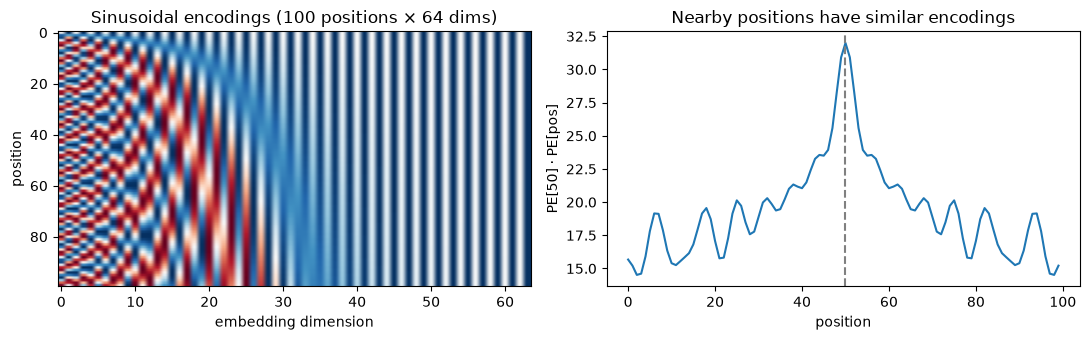

In [20]:
def sinusoidal_encoding(max_len, d_model):
    pos = torch.arange(max_len, dtype=torch.float32)[:, None]            # (max_len, 1)
    i = torch.arange(0, d_model, 2, dtype=torch.float32)                  # 0, 2, 4, ...
    freq = 1.0 / (10_000 ** (i / d_model))                                # (d_model/2,)
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(pos * freq)
    pe[:, 1::2] = torch.cos(pos * freq)
    return pe


pe = sinusoidal_encoding(100, 64)
similarity = pe @ pe[50]                                                  # dot product of position 50 with all others

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].imshow(pe.numpy(), aspect="auto", cmap="RdBu")
axes[0].set(xlabel="embedding dimension", ylabel="position", title="Sinusoidal encodings (100 positions × 64 dims)")
axes[1].plot(similarity.numpy())
axes[1].axvline(50, color="gray", linestyle="--")
axes[1].set(xlabel="position", ylabel="PE[50] · PE[pos]", title="Nearby positions have similar encodings")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

By hand (with `math.sin` / `math.cos`), compute the sinusoidal encoding of **position 1** for `d_model = 4`. The two frequencies are `1/10000^(0/4) = 1` and `1/10000^(2/4) = 1/100`.

In [21]:
pe_pos1 = None  # TODO: a list or tensor of 4 numbers [sin, cos, sin, cos]
check("pe_pos1", pe_pos1, [0.8414710, 0.5403023, 0.0099998, 0.9999500],
      hint="[sin(1·1), cos(1·1), sin(1/100), cos(1/100)] — you can compare with sinusoidal_encoding(2, 4)[1].")

⏳ pe_pos1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pe_pos1 = [math.sin(1.0), math.cos(1.0), math.sin(1 / 100), math.cos(1 / 100)]
check("pe_pos1", pe_pos1, sinusoidal_encoding(2, 4)[1])
```
</details>

### RoPE — Rotary Position Embedding (used by Llama, Mistral, Qwen)

Instead of *adding* a vector to the embeddings once, **RoPE rotates the query and key vectors inside every attention layer**. Split `q` into pairs of numbers; rotate pair `i` by angle `pos × θ_i`, where $\theta_i = 10000^{-2i/d}$.

```
  pair (x_even, x_odd) at position m  ──rotate by m·θ──►  (x_even·cos − x_odd·sin,  x_even·sin + x_odd·cos)
```

**Why it's clever:** rotating `q` by angle `mθ` and `k` by angle `nθ` makes their dot product depend only on the **difference** `m − n`. So attention naturally sees *relative* position ("3 tokens back"), with no extra parameters. Values `v` are not rotated.

In [22]:
def rope_cache(max_len, d_head, base=10_000.0):
    """cos/sin tables of shape (max_len, d_head // 2)."""
    inv_freq = 1.0 / base ** (torch.arange(0, d_head, 2, dtype=torch.float64) / d_head)   # θ_i
    angles = torch.outer(torch.arange(max_len, dtype=torch.float64), inv_freq)            # (max_len, d_head/2)
    return angles.cos().float(), angles.sin().float()


def apply_rope(x, cos, sin):
    """x: (..., T, d_head); cos/sin: (T, d_head/2) for the positions of these T tokens."""
    x_even, x_odd = x[..., 0::2], x[..., 1::2]
    rotated_even = x_even * cos - x_odd * sin
    rotated_odd = x_even * sin + x_odd * cos
    return torch.stack([rotated_even, rotated_odd], dim=-1).flatten(-2)   # interleave back


d_head_demo = 8
cos_demo, sin_demo = rope_cache(64, d_head_demo)
torch.manual_seed(0)
q_vec, k_vec = torch.randn(d_head_demo), torch.randn(d_head_demo)


def rope_at(vec, pos):
    return apply_rope(vec[None, :], cos_demo[pos:pos + 1], sin_demo[pos:pos + 1])[0]


pairs = [(5, 3), (12, 10), (40, 38)]                                       # all have offset m − n = 2
dots = [(rope_at(q_vec, m) @ rope_at(k_vec, n)).item() for m, n in pairs]
for (m, n), d in zip(pairs, dots):
    print(f"q at position {m:2d}, k at position {n:2d} (offset 2) → q·k = {d:.5f}")
assert np.allclose(dots, dots[0], atol=1e-4)
print("same offset → same dot product ✅ (RoPE encodes RELATIVE position)")

print("offset 0 vs 10 vs 30:", [round((rope_at(q_vec, 30 + o) @ rope_at(k_vec, 30)).item(), 3) for o in (0, 10, 30)])
assert torch.allclose(rope_at(q_vec, 17).norm(), q_vec.norm(), atol=1e-5)
print("rotation keeps the vector length ✅")

q at position  5, k at position  3 (offset 2) → q·k = 0.03367
q at position 12, k at position 10 (offset 2) → q·k = 0.03367
q at position 40, k at position 38 (offset 2) → q·k = 0.03367
same offset → same dot product ✅ (RoPE encodes RELATIVE position)
offset 0 vs 10 vs 30: [-0.526, 0.828, -2.318]
rotation keeps the vector length ✅


> 💡 **Interview angle:** "Sinusoidal/learned positions vs RoPE?" — absolute encodings are **added once** to the input; RoPE **rotates q and k in every layer**, so `q·k` depends on relative offset, adds no parameters, and can be stretched for longer contexts by rescaling the rotation frequencies (position interpolation, NTK-aware scaling, YaRN).

## 9. The Transformer Block: LayerNorm, Residuals, MLP 🟡

A transformer is a stack of identical **blocks**. Each block has two sub-layers, each wrapped in a **residual connection** (`x + f(x)`) with **LayerNorm** first (**pre-LN**, used by GPT-2 and nearly all modern LLMs):

```
x ──┬──► LayerNorm ─► Multi-Head Attention ─┐
    └──────────────────────────────────────(+)──┬──► LayerNorm ─► MLP ─┐
                                                └──────────────────────(+)──► out

pre-LN  (GPT-2+):      x = x + Attn(LN(x));   x = x + MLP(LN(x))
post-LN (2017, BERT):  x = LN(x + Attn(x));   x = LN(x + MLP(x))
```

- **Attention** moves information *between* tokens. The **MLP** (Linear → GELU → Linear, hidden size 4·d_model) processes each token *on its own*.
- **Residual connection:** the block only learns a *change* to `x`; gradients flow straight through the `+`.
- **LayerNorm:** rescales each token's vector to mean 0 and variance 1 across its features, then applies a learned scale and shift.

In [23]:
def layer_norm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)                         # over FEATURES of each token
    var = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return gamma * (x - mean) / torch.sqrt(var + eps) + beta


torch.manual_seed(0)
x_ln = torch.randn(4, 10, 32) * 5 + 3
torch_ln = nn.LayerNorm(32)
assert torch.allclose(layer_norm(x_ln, torch_ln.weight, torch_ln.bias), torch_ln(x_ln), atol=1e-5)
print("our LayerNorm == nn.LayerNorm ✅")

# LayerNorm vs BatchNorm: does a token's output depend on OTHER sequences in the batch?
batch_norm = nn.BatchNorm1d(32)                                 # normalizes each feature over the batch
x_other = x_ln.clone()
x_other[1:] = torch.randn(3, 10, 32) * 50                       # replace the other 3 sequences

ln_same = torch.allclose(torch_ln(x_ln)[0], torch_ln(x_other)[0])
bn_a = batch_norm(x_ln.reshape(-1, 32)).reshape(4, 10, 32)[0]
bn_b = batch_norm(x_other.reshape(-1, 32)).reshape(4, 10, 32)[0]
print(f"LayerNorm output of sequence 0 unchanged when the rest of the batch changes: {ln_same}")
print(f"BatchNorm output of sequence 0 unchanged when the rest of the batch changes: {torch.allclose(bn_a, bn_b)}")

our LayerNorm == nn.LayerNorm ✅
LayerNorm output of sequence 0 unchanged when the rest of the batch changes: True
BatchNorm output of sequence 0 unchanged when the rest of the batch changes: False


In [24]:
class MLP(nn.Module):
    def __init__(self, d_model, bias=False):
        super().__init__()
        self.fc = nn.Linear(d_model, 4 * d_model, bias=bias)
        self.proj = nn.Linear(4 * d_model, d_model, bias=bias)

    def forward(self, x):
        return self.proj(F.gelu(self.fc(x)))


class TransformerBlock(nn.Module):
    """Pre-LN block built from our MultiHeadAttention (Section 7)."""

    def __init__(self, d_model, n_heads, residual=True):
        super().__init__()
        self.residual = residual
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.mlp = MLP(d_model)

    def forward(self, x, mask=None):
        a, _ = self.attn(self.ln1(x), mask=mask)
        x = x + a if self.residual else a
        m = self.mlp(self.ln2(x))
        return x + m if self.residual else m


# Why residuals? Measure how much gradient reaches the input of a 24-block stack.
grad_at_input = {}
for residual in (True, False):
    torch.manual_seed(0)
    stack = nn.ModuleList([TransformerBlock(64, 4, residual=residual) for _ in range(24)])
    x_in = torch.randn(8, 16, 64, requires_grad=True)
    h = x_in
    for blk in stack:
        h = blk(h)
    h.pow(2).mean().backward()
    grad_at_input[residual] = x_in.grad.norm().item()
    print(f"residual={residual!s:5} → gradient norm at the input: {grad_at_input[residual]:.2e}")
print(f"→ residual connections deliver {grad_at_input[True] / grad_at_input[False]:.0f}× more gradient to the first layer")

residual=True  → gradient norm at the input: 9.05e-02
residual=False → gradient norm at the input: 3.09e-03
→ residual connections deliver 29× more gradient to the first layer


> 💡 **Interview angle:** "LayerNorm vs BatchNorm — and why pre-LN?" — BatchNorm normalizes each feature **across the batch** (depends on other examples, needs running statistics, awkward for variable-length text and batch-size-1 generation); LayerNorm normalizes each token **across its features**, identical at training and inference. Pre-LN keeps a clean residual path, so deep stacks train stably with less learning-rate warmup; post-LN (original Transformer, BERT) is harder to train deep. Llama-style models use **RMSNorm** (no mean-centering, no bias).

## 10. Encoder, Decoder, and Encoder–Decoder 🟢

The **same block** becomes three families depending on the mask and wiring:

| Family | Attention | Trained to | Good at | Examples |
|---|---|---|---|---|
| **Encoder-only** | bidirectional (no causal mask) | fill in masked tokens | classification, embeddings, search | BERT, RoBERTa, sentence-transformers |
| **Decoder-only** | causal | predict the next token | open-ended generation, chat, code | GPT family, Llama, Mistral, Qwen, Gemma |
| **Encoder–decoder** | encoder bidirectional + causal decoder with **cross-attention** | map an input sequence to an output sequence | translation, summarization, speech-to-text | original Transformer, T5, BART, Whisper |

**Cross-attention**: queries come from the decoder, keys and values from the encoder's output — "while writing the translation, look at the source sentence".

In [25]:
torch.manual_seed(0)
block = TransformerBlock(48, 6)
x_enc = torch.randn(1, 7, 48)
causal7 = torch.ones(7, 7, dtype=torch.bool).tril()
print("encoder block (no mask) sees future tokens?    ", future_leaks(lambda z: block(z), x_enc, atol=1e-5))
print("decoder block (causal mask) sees future tokens?", future_leaks(lambda z: block(z, mask=causal7), x_enc, atol=1e-5))

# Cross-attention: 4 decoder tokens attend over 7 encoder tokens
cross_attn = MultiHeadAttention(48, 6)
decoder_states = torch.randn(1, 4, 48)
encoder_output = block(x_enc)
cross_out, cross_w = cross_attn(decoder_states, x_kv=encoder_output)
print("cross-attention weights shape:", tuple(cross_w.shape), "= (B, heads, T_decoder, T_encoder)")
print("cross-attention output shape :", tuple(cross_out.shape), "= decoder length, not encoder length")

encoder block (no mask) sees future tokens?     True
decoder block (causal mask) sees future tokens? False
cross-attention weights shape: (1, 6, 4, 7) = (B, heads, T_decoder, T_encoder)
cross-attention output shape : (1, 4, 48) = decoder length, not encoder length


> 💡 **Interview angle:** "Why are most LLMs decoder-only?" — one simple objective (next token) works on any raw text and scales well, generation is natural, and the KV cache makes decoding efficient. Encoders still win for embeddings/classification per unit of compute; encoder–decoders suit input→output tasks like speech recognition (Whisper).

## 11. Assembling a Mini GPT and Counting Parameters 🟡

Now the production-style version: a **decoder-only GPT** with pre-LN blocks, **RoPE**, weight tying, and a **KV cache** hook (used in Section 14). The attention can run through our own `attention()` or PyTorch's fused kernel (`use_sdpa=True`) — Build It From Scratch proves they are identical.

```
ids (B,T) → token embedding (B,T,d) → [Block × n_layers] → LayerNorm → head (tied to embedding) → logits (B,T,vocab)
```

In [26]:
@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int = 256      # maximum context length
    d_model: int = 192
    n_heads: int = 6
    n_layers: int = 4
    dropout: float = 0.1


class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_heads, self.d_head = cfg.n_heads, cfg.d_model // cfg.n_heads
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)   # q, k, v in one matmul
        self.proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.use_sdpa = False

    def forward(self, x, cos, sin, kv_cache=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q, k, v = (t.view(B, T, self.n_heads, self.d_head).transpose(1, 2) for t in (q, k, v))
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)          # rotate queries and keys only
        if kv_cache is not None:                                          # prepend keys/values of earlier tokens
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        S = k.size(2)                                                     # total tokens visible so far
        if self.use_sdpa and T == S:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        else:
            # query i sits at absolute position S - T + i and may see keys 0 .. S - T + i
            mask = torch.ones(T, S, dtype=torch.bool, device=x.device).tril(diagonal=S - T)
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=mask) if self.use_sdpa else attention(q, k, v, mask)[0]
        y = y.transpose(1, 2).reshape(B, T, C)
        return self.proj(y), (k, v)


class GPTBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(cfg.d_model), nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.mlp = MLP(cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, cos, sin, kv_cache=None):
        a, new_cache = self.attn(self.ln1(x), cos, sin, kv_cache)
        x = x + self.drop(a)
        x = x + self.drop(self.mlp(self.ln2(x)))
        return x, new_cache


class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([GPTBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight                            # weight tying
        cos, sin = rope_cache(cfg.block_size, cfg.d_model // cfg.n_heads)
        self.register_buffer("rope_cos", cos, persistent=False)
        self.register_buffer("rope_sin", sin, persistent=False)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)            # small init → initial loss ≈ ln(vocab)

    def set_fused_attention(self, flag):
        for blk in self.blocks:
            blk.attn.use_sdpa = flag

    def forward(self, idx, targets=None, kv_caches=None):
        B, T = idx.shape
        start = 0 if kv_caches is None else kv_caches[0][0].size(2)      # position of the first new token
        assert start + T <= self.cfg.block_size, "sequence longer than block_size"
        cos, sin = self.rope_cos[start:start + T], self.rope_sin[start:start + T]
        x = self.drop(self.tok_emb(idx))
        new_caches = []
        for i, blk in enumerate(self.blocks):
            x, cache = blk(x, cos, sin, None if kv_caches is None else kv_caches[i])
            new_caches.append(cache)
        logits = self.head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))   # reshape: targets may be a non-contiguous slice
        return logits, loss, new_caches


def count_params(model):
    return sum(p.numel() for p in model.parameters())                   # shared (tied) tensors are counted once


mini_cfg = GPTConfig(vocab_size=vocab_size)
mini_gpt = GPT(mini_cfg)
logits_demo, loss_demo, _ = mini_gpt(data[:32].view(1, -1), targets=data[1:33].view(1, -1))
print("logits shape:", tuple(logits_demo.shape), "= (B, T, vocab)")
print(f"loss at initialization: {loss_demo.item():.3f} | ln(vocab) = {math.log(vocab_size):.3f}  ← a random model should be close to this")

logits shape: (1, 32, 65) = (B, T, vocab)
loss at initialization: 4.172 | ln(vocab) = 4.174  ← a random model should be close to this


### Counting parameters by formula

For our GPT (no biases in linear layers, tied head, RoPE has no parameters):

| Part | Parameters |
|---|---|
| token embedding (shared with head) | `V · d` |
| attention per block (q, k, v, out) | `4 d²` |
| MLP per block (d → 4d → d) | `8 d²` |
| 2 LayerNorms per block (scale + shift) | `4 d` |
| final LayerNorm | `2 d` |

**Total ≈ `V·d + L·(12d² + 4d) + 2d`** — the famous "**12·L·d²**" rule of thumb for the blocks.

In [27]:
def gpt_param_formula(V, d, L):
    return V * d + L * (12 * d * d + 4 * d) + 2 * d


formula = gpt_param_formula(vocab_size, mini_cfg.d_model, mini_cfg.n_layers)
print(f"mini GPT: counted {count_params(mini_gpt):,} | formula {formula:,}")
assert count_params(mini_gpt) == formula

# GPT-2 small (2019) has biases and learned position embeddings: V·d + T·d + L·(12d² + 13d) + 2d
V2, T2, d2, L2 = 50_257, 1024, 768, 12
gpt2_formula = V2 * d2 + T2 * d2 + L2 * (12 * d2 * d2 + 13 * d2) + 2 * d2
print(f"GPT-2 small by formula: {gpt2_formula:,} (embeddings are {(V2 * d2 + T2 * d2) / gpt2_formula:.0%} of it)")

try:
    from transformers import GPT2Config, GPT2LMHeadModel

    with torch.device("meta"):                                           # build the shapes only — no memory, no download
        hf_gpt2 = GPT2LMHeadModel(GPT2Config())
    print(f"Hugging Face GPT-2    : {count_params(hf_gpt2):,}")
    assert count_params(hf_gpt2) == gpt2_formula
    print("formula matches the real GPT-2 architecture ✅")
except ImportError as err:
    print(f"⏭️ Skipped Hugging Face comparison: {err}")

mini GPT: counted 1,785,408 | formula 1,785,408
GPT-2 small by formula: 124,439,808 (embeddings are 32% of it)


Hugging Face GPT-2    : 124,439,808
formula matches the real GPT-2 architecture ✅


### ✍️ Your Turn

Use the formula to compute the parameter count of a GPT with `V = 65`, `d = 256`, `L = 4` **without** building the model. The checker builds the real model to compare.

In [28]:
my_param_count = None  # TODO: your code here
check("my_param_count", my_param_count, count_params(GPT(GPTConfig(vocab_size=65, d_model=256, n_heads=4, n_layers=4))),
      hint="V·d + L·(12·d² + 4·d) + 2·d")

⏳ my_param_count: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
V, d, L = 65, 256, 4
my_param_count = V * d + L * (12 * d * d + 4 * d) + 2 * d     # 3,166,976
check("my_param_count", my_param_count, count_params(GPT(GPTConfig(vocab_size=65, d_model=256, n_heads=4, n_layers=4))))
```
</details>

> 💡 **Interview angle:** "Estimate the parameters of a transformer" — say **12·L·d²** for the blocks plus **V·d** for embeddings. Then sanity-check: GPT-2 small (L=12, d=768) → 12·12·768² ≈ 85M in blocks + 38.6M embeddings ≈ 124M. Memory for weights ≈ params × bytes per parameter (2 bytes in fp16/bf16).

## 12. The O(n²) Cost of Attention 🔴

The attention score matrix has one entry **per pair** of tokens: `T × T`. Double the context → **4×** the scores. The MLP processes each token independently → only **2×**.

We time both on the CPU (steadier timings than a GPU for this small experiment). With tiny inputs, fixed overheads hide the trend, so we go up to 4,096 tokens.

T=  256 | attention      0.4 ms | MLP   0.31 ms | score matrix     1.0 MB
T=  512 | attention      1.8 ms | MLP   0.55 ms | score matrix     4.0 MB
T= 1024 | attention      9.5 ms | MLP   1.00 ms | score matrix    16.0 MB


T= 2048 | attention     46.0 ms | MLP   1.69 ms | score matrix    64.0 MB


T= 4096 | attention    199.4 ms | MLP   4.44 ms | score matrix   256.0 MB

when T doubles (largest sizes): attention time × 4.8, MLP time × 2.0
→ attention is quadratic in sequence length, the MLP is linear


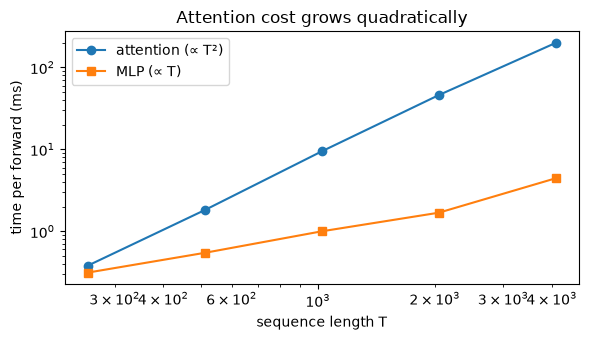

A naive 128k-token score matrix (32 heads, fp16, one layer) would need 977 GB — which is why FlashAttention never materializes it.


In [29]:
torch.manual_seed(0)
lengths_t = [256, 512, 1024, 2048, 4096]
n_heads_t, d_head_t = 4, 64
mlp_t = MLP(n_heads_t * d_head_t)
attn_ms, mlp_ms, attn_mb = [], [], []


def time_ms(fn, repeats=3):
    fn()                                                                   # warm-up
    start = time.perf_counter()
    for _ in range(repeats):
        fn()
    return (time.perf_counter() - start) / repeats * 1000


with torch.no_grad():
    for T_len in lengths_t:
        qt = torch.randn(1, n_heads_t, T_len, d_head_t)
        xt = torch.randn(1, T_len, n_heads_t * d_head_t)
        attn_ms.append(time_ms(lambda: attention(qt, qt, qt)))
        mlp_ms.append(time_ms(lambda: mlp_t(xt)))
        attn_mb.append(1 * n_heads_t * T_len * T_len * 4 / 2**20)          # B·h·T²·4 bytes (float32 scores)
        print(f"T={T_len:5d} | attention {attn_ms[-1]:8.1f} ms | MLP {mlp_ms[-1]:6.2f} ms | score matrix {attn_mb[-1]:7.1f} MB")

attn_growth = np.mean(np.array(attn_ms[2:]) / np.array(attn_ms[1:-1]))
mlp_growth = np.mean(np.array(mlp_ms[2:]) / np.array(mlp_ms[1:-1]))
print(f"\nwhen T doubles (largest sizes): attention time × {attn_growth:.1f}, MLP time × {mlp_growth:.1f}")
print("→ attention is quadratic in sequence length, the MLP is linear" if attn_growth > 1.5 * mlp_growth else "→ trend unclear on this machine; try larger T")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.loglog(lengths_t, attn_ms, "o-", label="attention (∝ T²)")
ax.loglog(lengths_t, mlp_ms, "s-", label="MLP (∝ T)")
ax.set(xlabel="sequence length T", ylabel="time per forward (ms)", title="Attention cost grows quadratically")
ax.legend()
plt.tight_layout()
plt.show()

full_matrix_gb = 1 * 32 * 128_000**2 * 2 / 2**30                            # 32 heads, fp16, ONE layer, 128k tokens
print(f"A naive 128k-token score matrix (32 heads, fp16, one layer) would need {full_matrix_gb:,.0f} GB — "
      "which is why FlashAttention never materializes it.")

> 💡 **Interview angle:** "Attention complexity and long context?" — O(T²·d) time and O(T²) memory if the score matrix is materialized. **FlashAttention** computes *exact* attention in blocks that fit in fast GPU memory, so memory drops to O(T) and it runs faster — but compute is still O(T²). **Sliding-window attention** (Mistral, Longformer) limits each token to the last *w* tokens → O(T·w). **GQA/MQA** shrink the KV cache for decoding.

## 13. Sampling: Greedy, Temperature, Top-k, Top-p 🟡

The model outputs **logits** (raw scores) for the next token. How we turn them into a choice changes the text a lot:

| Strategy | Rule | Effect |
|---|---|---|
| **Greedy** | pick the argmax | deterministic, often repetitive |
| **Temperature τ** | softmax(logits / τ) | τ < 1 sharper (safer), τ > 1 flatter (more random), τ → 0 = greedy |
| **Top-k** | keep only the k highest logits | cuts off the long tail of nonsense |
| **Top-p (nucleus)** | keep the smallest set whose probabilities sum to ≥ p | adapts: few candidates when confident, many when unsure |

In [30]:
def top_k_filter(logits, k):
    kth_best = torch.topk(logits, k, dim=-1).values[..., -1, None]
    return logits.masked_fill(logits < kth_best, float("-inf"))


def top_p_filter(logits, p):
    sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
    probs = torch.softmax(sorted_logits, dim=-1)
    mass_before = probs.cumsum(dim=-1) - probs                          # probability of strictly better tokens
    sorted_logits = sorted_logits.masked_fill(mass_before >= p, float("-inf"))   # the top token is always kept
    return torch.full_like(logits, float("-inf")).scatter(-1, sorted_idx, sorted_logits)


def sample_next(logits, temperature=1.0, top_k=None, top_p=None):
    """logits: (B, vocab) → next ids (B, 1)."""
    if temperature == 0:
        return logits.argmax(dim=-1, keepdim=True)                      # greedy
    logits = logits / temperature
    if top_k is not None:
        logits = top_k_filter(logits, top_k)
    if top_p is not None:
        logits = top_p_filter(logits, top_p)
    return torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)


words = ["the", "a", "cat", "dog", "banana", "quantum"]
toy_logits = torch.tensor([3.0, 2.5, 2.0, 1.5, 0.0, -2.0])
settings = {
    "τ=1.0": torch.softmax(toy_logits, -1),
    "τ=0.5": torch.softmax(toy_logits / 0.5, -1),
    "τ=2.0": torch.softmax(toy_logits / 2.0, -1),
    "top-k=3": torch.softmax(top_k_filter(toy_logits, 3), -1),
    "top-p=0.75": torch.softmax(top_p_filter(toy_logits, 0.75), -1),
}
print(f"{'':11s}" + "".join(f"{w:>9s}" for w in words))
for name, probs in settings.items():
    print(f"{name:11s}" + "".join(f"{p:9.3f}" for p in probs.tolist()))
print("greedy     →", words[sample_next(toy_logits[None], temperature=0).item()])

torch.manual_seed(0)
draws = torch.cat([sample_next(toy_logits[None].expand(20_000, -1), temperature=1.0)]).flatten()
empirical = torch.bincount(draws, minlength=len(words)).float() / len(draws)
print(f"\n20,000 samples at τ=1 — largest gap between sampled frequency and softmax probability: "
      f"{(empirical - settings['τ=1.0']).abs().max().item():.4f}")

                 the        a      cat      dog   banana  quantum
τ=1.0          0.444    0.269    0.163    0.099    0.022    0.003
τ=0.5          0.643    0.236    0.087    0.032    0.002    0.000
τ=2.0          0.316    0.246    0.192    0.149    0.071    0.026
top-k=3        0.506    0.307    0.186    0.000    0.000    0.000
top-p=0.75     0.506    0.307    0.186    0.000    0.000    0.000
greedy     → the

20,000 samples at τ=1 — largest gap between sampled frequency and softmax probability: 0.0047


### ✍️ Your Turn

Compute the probabilities for `logits = [2.0, 1.0, 0.0]` at **temperature 0.5**.

In [31]:
temp_logits = torch.tensor([2.0, 1.0, 0.0])
temp_probs = None  # TODO: your code here
check("temp_probs", temp_probs, [0.86681, 0.11731, 0.01588], hint="Divide the logits by the temperature, then softmax.")

⏳ temp_probs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
temp_logits = torch.tensor([2.0, 1.0, 0.0])
temp_probs = torch.softmax(temp_logits / 0.5, dim=-1)
check("temp_probs", temp_probs, [0.86681, 0.11731, 0.01588])
```
Dividing by 0.5 doubles the gaps between logits, so the top token's probability rises from 0.665 (τ=1) to 0.867.
</details>

> 💡 **Interview angle:** "What does top-p = 0.9 do?" — keeps the **smallest** set of most-likely tokens whose total probability reaches 90%, renormalizes, and samples; the number of candidates changes every step. It is **not** "keep 90% of tokens". Temperature 0 (greedy) is typical for extraction/classification; ~0.7 with top-p 0.9–0.95 for creative text.

## 14. Generation and the KV Cache 🔴

Generation is a loop: run the model, sample one token, append it, repeat. Without a cache, step `t` re-runs the **whole** sequence of `t` tokens through every layer — even though the keys and values of the old tokens haven't changed.

A **KV cache** stores each layer's keys and values. Each new step feeds only the **one new token**, computes its q, k, v, appends k and v to the cache, and attends over the cache.

```
no cache : step 1 [x1]   step 2 [x1 x2]   step 3 [x1 x2 x3]   ...   total work ∝ T²
KV cache : step 1 [x1]   step 2 [x2] + cached K,V(x1)   step 3 [x3] + cached K,V(x1,x2)   ∝ T
```

**Memory:** `2 × n_layers × n_kv_heads × d_head × seq_len × batch × bytes_per_value` (the 2 is for K **and** V).

**Speed:** for a tiny model on a GPU, each step spends much of its time just launching kernels, so the cache matters little for short outputs. The savings grow with sequence length. Below we measure two lengths on your accelerator and on the CPU.

In [32]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, use_cache=True, temperature=0.0, top_k=None, top_p=None):
    """idx: (B, T) prompt ids → (B, T + max_new_tokens). Total length must fit in block_size."""
    model.eval()
    assert idx.size(1) + max_new_tokens <= model.cfg.block_size
    caches = None
    for _ in range(max_new_tokens):
        if use_cache:
            step_input = idx if caches is None else idx[:, -1:]        # whole prompt once, then 1 token per step
            logits, _, caches = model(step_input, kv_caches=caches)
        else:
            logits, _, _ = model(idx)                                   # recompute everything every step
        next_id = sample_next(logits[:, -1, :], temperature, top_k, top_p)
        idx = torch.cat([idx, next_id], dim=1)
    return idx


torch.manual_seed(0)
bench_cfg = GPTConfig(vocab_size=vocab_size, block_size=1024)            # mini-project width/depth, longer context (untrained)
speedups = {}
for device in dict.fromkeys([DEVICE, torch.device("cpu")]):               # your accelerator (if any) and the CPU
    kv_model = GPT(bench_cfg).to(device)
    prompt = torch.tensor([encode_chars("\n")], device=device)
    generate(kv_model, prompt, 8, use_cache=False)                         # warm-up (kernel setup)
    generate(kv_model, prompt, 8, use_cache=True)
    for n_new in (127, 1023):
        seconds, outputs = {}, {}
        for use_cache in (False, True):
            sync()
            start = time.perf_counter()
            outputs[use_cache] = generate(kv_model, prompt, n_new, use_cache=use_cache)
            sync()
            seconds[use_cache] = time.perf_counter() - start
        agree = (outputs[False] == outputs[True]).float().mean().item()
        if n_new == 127:
            assert agree == 1.0, "cached and uncached greedy generation should match"
        speedups[(device.type, n_new)] = seconds[False] / seconds[True]
        print(f"{device.type:4s} | {n_new:5d} new tokens | no cache {seconds[False]:6.2f} s | KV cache {seconds[True]:5.2f} s | "
              f"speed-up {speedups[(device.type, n_new)]:4.1f}× | same tokens: {agree:.0%}")

for dev_type in dict.fromkeys(d for d, _ in speedups):
    short, long = speedups[(dev_type, 127)], speedups[(dev_type, 1023)]
    trend = "grows" if long > short else "does not grow"
    print(f"→ {dev_type}: the cache's speed-up {trend} with length ({short:.1f}× at 127 tokens → {long:.1f}× at 1023)")

mps  |   127 new tokens | no cache   0.88 s | KV cache  0.45 s | speed-up  2.0× | same tokens: 100%


mps  |  1023 new tokens | no cache   7.51 s | KV cache  4.24 s | speed-up  1.8× | same tokens: 100%


cpu  |   127 new tokens | no cache   0.55 s | KV cache  0.24 s | speed-up  2.3× | same tokens: 100%


cpu  |  1023 new tokens | no cache  18.14 s | KV cache  1.03 s | speed-up 17.6× | same tokens: 100%
→ mps: the cache's speed-up does not grow with length (2.0× at 127 tokens → 1.8× at 1023)
→ cpu: the cache's speed-up grows with length (2.3× at 127 tokens → 17.6× at 1023)


Let's verify the memory formula against the real cache tensors, then apply it to a real model configuration.

In [33]:
mem_cfg = GPTConfig(vocab_size=vocab_size)
mem_model = GPT(mem_cfg).eval()
seq = 255
with torch.no_grad():
    _, _, caches = mem_model(data[:seq].view(1, -1))                     # the cache after reading 255 tokens
measured_bytes = sum(t.nelement() * t.element_size() for layer_cache in caches for t in layer_cache)
formula_bytes = 2 * mem_cfg.n_layers * mem_cfg.n_heads * (mem_cfg.d_model // mem_cfg.n_heads) * seq * 1 * 4
print(f"mini GPT cache for {seq} tokens: measured {measured_bytes:,} bytes | formula {formula_bytes:,} bytes")
assert measured_bytes == formula_bytes


def kv_cache_gib(n_layers, n_kv_heads, d_head, seq_len, batch=1, bytes_per_value=2):
    return 2 * n_layers * n_kv_heads * d_head * seq_len * batch * bytes_per_value / 2**30


# Llama-3-8B-style config: 32 layers, 32 query heads, 8 KV heads, d_head 128, fp16
for name, kv_heads in [("MHA (32 KV heads)", 32), ("GQA (8 KV heads) ", 8), ("MQA (1 KV head)  ", 1)]:
    print(f"{name}: {kv_cache_gib(32, kv_heads, 128, seq_len=8192):5.2f} GiB per 8k-token sequence")

mini GPT cache for 255 tokens: measured 1,566,720 bytes | formula 1,566,720 bytes
MHA (32 KV heads):  4.00 GiB per 8k-token sequence
GQA (8 KV heads) :  1.00 GiB per 8k-token sequence
MQA (1 KV head)  :  0.12 GiB per 8k-token sequence


> 💡 **Interview angle:** "What does the KV cache store and how big is it?" — keys and values (not queries) for every past token in every layer: `2·L·n_kv_heads·d_head·T·batch·bytes`. For Llama-3-8B at 8k tokens in fp16 that's ~1 GiB **per sequence**, which is why serving systems use GQA/MQA, KV-cache quantization, and **PagedAttention** (vLLM) to fit more concurrent requests.

## 🔧 Build It From Scratch

Everything above was hand-written. Now we **prove** it matches PyTorch's optimized implementations — the same check you'd write before trusting custom attention code in production.

### 1) Our `attention()` vs `F.scaled_dot_product_attention`

We compare in float64 on the CPU so any mismatch is a real bug, not rounding.

In [34]:
torch.manual_seed(0)
B_c, h_c, T_c, d_c = 2, 4, 9, 16
q64, k64, v64 = (torch.randn(B_c, h_c, T_c, d_c, dtype=torch.float64) for _ in range(3))

# a) no mask
ours, _ = attention(q64, k64, v64)
assert torch.allclose(ours, F.scaled_dot_product_attention(q64, k64, v64))
print("✅ no mask")

# b) causal: our lower-triangular mask vs is_causal=True
causal_c = torch.ones(T_c, T_c, dtype=torch.bool).tril()
ours, _ = attention(q64, k64, v64, mask=causal_c)
assert torch.allclose(ours, F.scaled_dot_product_attention(q64, k64, v64, is_causal=True))
print("✅ causal mask (is_causal=True)")

# c) padding + causal boolean mask (True = attend, same convention as SDPA)
lengths_c = torch.tensor([9, 5])
pad_c = (torch.arange(T_c)[None, :] < lengths_c[:, None])[:, None, None, :]
both = pad_c & causal_c
ours, _ = attention(q64, k64, v64, mask=both)
assert torch.allclose(ours, F.scaled_dot_product_attention(q64, k64, v64, attn_mask=both))
print("✅ padding + causal boolean mask")

# d) cross-attention with different query and key lengths
q_short = torch.randn(B_c, h_c, 3, d_c, dtype=torch.float64)
ours, _ = attention(q_short, k64, v64)
assert torch.allclose(ours, F.scaled_dot_product_attention(q_short, k64, v64))
print("✅ cross-attention (T_q=3, T_k=9)")

# e) grouped-query attention: 4 query heads share 2 key/value heads
k_gqa, v_gqa = k64[:, :2], v64[:, :2]
ours, _ = attention(q64, k_gqa.repeat_interleave(2, dim=1), v_gqa.repeat_interleave(2, dim=1), mask=causal_c)
assert torch.allclose(ours, F.scaled_dot_product_attention(q64, k_gqa, v_gqa, is_causal=True, enable_gqa=True))
print("✅ grouped-query attention (enable_gqa=True)")

✅ no mask
✅ causal mask (is_causal=True)
✅ padding + causal boolean mask
✅ cross-attention (T_q=3, T_k=9)
✅ grouped-query attention (enable_gqa=True)


### 2) Our `MultiHeadAttention` vs `nn.MultiheadAttention`

Copy our weights into PyTorch's module and compare outputs **and** per-head attention weights. Note PyTorch's `nn.MultiheadAttention` uses the **opposite** boolean mask convention (`True` = blocked), so we pass `~mask`.

In [35]:
torch.manual_seed(0)
d_m, h_m = 32, 4
ours_mha = MultiHeadAttention(d_m, h_m).double()
torch_mha = nn.MultiheadAttention(d_m, h_m, bias=False, batch_first=True).double()
with torch.no_grad():
    torch_mha.in_proj_weight.copy_(torch.cat([ours_mha.w_q.weight, ours_mha.w_k.weight, ours_mha.w_v.weight]))
    torch_mha.out_proj.weight.copy_(ours_mha.w_o.weight)

x_m = torch.randn(2, 7, d_m, dtype=torch.float64)
keep = torch.ones(7, 7, dtype=torch.bool).tril()
ours_out, ours_w = ours_mha(x_m, mask=keep)
torch_out, torch_w = torch_mha(x_m, x_m, x_m, attn_mask=~keep, average_attn_weights=False)
assert torch.allclose(ours_out, torch_out) and torch.allclose(ours_w, torch_w)
print("✅ MultiHeadAttention matches nn.MultiheadAttention (outputs and per-head weights)")

✅ MultiHeadAttention matches nn.MultiheadAttention (outputs and per-head weights)


### 3) Our GPT: hand-written attention vs the fused kernel, and cache vs no cache

If the whole model gives identical logits either way, we can safely train with the faster kernel.

In [36]:
torch.manual_seed(0)
check_gpt = GPT(GPTConfig(vocab_size=vocab_size, block_size=64, d_model=48, n_heads=4, n_layers=2, dropout=0.0)).double().eval()
ids_c = data[:40].view(1, -1)
with torch.no_grad():
    logits_ours, _, _ = check_gpt(ids_c)
    check_gpt.set_fused_attention(True)
    logits_fused, _, _ = check_gpt(ids_c)
    _, _, prefix_cache = check_gpt(ids_c[:, :30])                         # cache the first 30 tokens...
    logits_cached, _, _ = check_gpt(ids_c[:, 30:], kv_caches=prefix_cache)   # ...then feed the last 10
assert torch.allclose(logits_ours, logits_fused)
assert torch.allclose(logits_ours[:, 30:], logits_cached)
print("✅ our attention == fused SDPA inside the full GPT")
print("✅ prefix KV cache + 10 new tokens == full forward pass (the bottom-right-aligned mask works)")

✅ our attention == fused SDPA inside the full GPT
✅ prefix KV cache + 10 new tokens == full forward pass (the bottom-right-aligned mask works)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — `is_causal=True` with a KV cache

During cached decoding the query has length 1 but the keys have length S. PyTorch's `is_causal=True` builds a **top-left** aligned mask, so the new token may only see the **first** key — silently wrong.

In [37]:
torch.manual_seed(0)
q_new = torch.randn(1, 2, 1, 8)                                            # one new token
k_all, v_all = torch.randn(1, 2, 6, 8), torch.randn(1, 2, 6, 8)            # 5 cached tokens + itself

wrong = F.scaled_dot_product_attention(q_new, k_all, v_all, is_causal=True)          # ❌
right = F.scaled_dot_product_attention(q_new, k_all, v_all)                          # ✅ the newest token may see everything
print("❌ is_causal=True output equals value of token 0 only:", torch.allclose(wrong, v_all[:, :, :1]))
print("✅ no mask for the single newest token → differs from the wrong one:", not torch.allclose(wrong, right))

❌ is_causal=True output equals value of token 0 only: True
✅ no mask for the single newest token → differs from the wrong one: True


### ❌ Pitfall 2 — Mixing up boolean mask conventions

`F.scaled_dot_product_attention`: `True` = **attend**. `nn.MultiheadAttention`: `True` = **block**. Passing the same mask to both flips it: the model sees only the future, and the last row is fully blocked → `nan`.

In [38]:
torch.manual_seed(0)
mha_pt = nn.MultiheadAttention(8, 2, bias=False, batch_first=True)
x_p2 = torch.randn(1, 4, 8)
keep_mask = torch.ones(4, 4, dtype=torch.bool).tril()                     # True = may attend

wrong_out, _ = mha_pt(x_p2, x_p2, x_p2, attn_mask=keep_mask)             # ❌ interpreted as "block the past"
print("❌ nan in output:", torch.isnan(wrong_out).any().item(),
      "| leaks future:", future_leaks(lambda z: mha_pt(z, z, z, attn_mask=keep_mask)[0].nan_to_num(), x_p2))
right_out, _ = mha_pt(x_p2, x_p2, x_p2, attn_mask=~keep_mask)            # ✅ invert for nn.MultiheadAttention
print("✅ nan in output:", torch.isnan(right_out).any().item(),
      "| leaks future:", future_leaks(lambda z: mha_pt(z, z, z, attn_mask=~keep_mask)[0], x_p2))

❌ nan in output: True | leaks future: True
✅ nan in output: False | leaks future: False


### ❌ Pitfall 3 — Merging heads without transposing back

`out` has shape `(B, h, T, d_head)`. Calling `reshape(B, T, C)` directly gives the right *shape* but glues together numbers from **different positions** — including future ones. No error, just a model that cheats.

In [39]:
torch.manual_seed(0)
B3, T3, C3, h3 = 1, 6, 8, 2
x3 = torch.randn(B3, T3, C3)


def mha_merge(x, transpose_back):
    s = x.view(B3, T3, h3, C3 // h3).transpose(1, 2)                      # (B, h, T, d_head)
    out = F.scaled_dot_product_attention(s, s, s, is_causal=True)
    if transpose_back:
        return out.transpose(1, 2).reshape(B3, T3, C3)                    # ✅ (B, T, h, d_head) → (B, T, C)
    return out.reshape(B3, T3, C3)                                        # ❌ same shape, scrambled positions


print("❌ reshape without transpose leaks the future:", future_leaks(lambda z: mha_merge(z, False), x3))
print("✅ transpose(1, 2) then reshape leaks the future:", future_leaks(lambda z: mha_merge(z, True), x3))

❌ reshape without transpose leaks the future: True
✅ transpose(1, 2) then reshape leaks the future: False


### ❌ Pitfall 4 — A fully masked row turns into `nan`

In a padded batch, a padding **query** may have no allowed keys. `softmax` over all `-inf` returns `nan`, which then poisons the loss and every gradient.

In [40]:
scores_p4 = torch.tensor([[1.0, 2.0, 0.5], [0.3, 0.1, 0.2]])
mask_p4 = torch.tensor([[True, True, False], [False, False, False]])      # row 2 = a padding query

weights_bad = torch.softmax(scores_p4.masked_fill(~mask_p4, float("-inf")), dim=-1)          # ❌
print("❌ weights:\n", weights_bad, "\n   loss would be:", weights_bad.sum().item())

weights_good = weights_bad.masked_fill(~mask_p4.any(dim=-1, keepdim=True), 0.0)             # ✅ zero rows with no allowed keys
print("✅ weights:\n", weights_good, "\n   loss is finite:", torch.isfinite(weights_good.sum()).item())
# ✅ also exclude padding positions from the loss, e.g. F.cross_entropy(..., ignore_index=PAD_ID)

❌ weights:
 tensor([[0.2689, 0.7311, 0.0000],
        [   nan,    nan,    nan]]) 
   loss would be: nan
✅ weights:
 tensor([[0.2689, 0.7311, 0.0000],
        [0.0000, 0.0000, 0.0000]]) 
   loss is finite: True


### ❌ Pitfall 5 — Forgetting to shift the targets

Next-token prediction needs `targets = inputs shifted left by one`. If `targets = inputs`, a causal model can simply **copy the current token**: the loss plunges toward 0, and generation is junk.

In [41]:
def quick_train(targets_shifted, steps=150):
    torch.manual_seed(0)
    tiny = GPT(GPTConfig(vocab_size=vocab_size, block_size=64, d_model=64, n_heads=4, n_layers=2, dropout=0.0)).to(DEVICE)
    tiny.set_fused_attention(True)
    opt = torch.optim.AdamW(tiny.parameters(), lr=3e-3)
    train_part = data[: int(0.8 * len(data))]
    for _ in range(steps):
        starts = torch.randint(len(train_part) - 65, (32,))
        chunk = torch.stack([train_part[s:s + 65] for s in starts]).to(DEVICE)
        x_b = chunk[:, :-1]
        y_b = chunk[:, 1:] if targets_shifted else chunk[:, :-1]
        _, loss, _ = tiny(x_b, targets=y_b)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
    prompt_ids = torch.tensor([encode_chars("ROMEO:\n")], device=DEVICE)
    sample = decode_chars(generate(tiny, prompt_ids, 50)[0].tolist())
    return loss.item(), sample


bad_loss, bad_sample = quick_train(targets_shifted=False)                 # ❌
good_loss, good_sample = quick_train(targets_shifted=True)                # ✅
print(f"❌ targets = inputs      → final train loss {bad_loss:.3f}  sample: {bad_sample!r}")
print(f"✅ targets shifted by 1  → final train loss {good_loss:.3f}  sample: {good_sample!r}")
print(f"(for reference, a model that knows nothing scores ln(vocab) = {math.log(vocab_size):.2f})")

❌ targets = inputs      → final train loss 0.010  sample: 'ROMEO:\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'
✅ targets shifted by 1  → final train loss 2.370  sample: 'ROMEO:\nThe the the the the the the the the the the the th'
(for reference, a model that knows nothing scores ln(vocab) = 4.17)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Causal mask
Create a boolean `(5, 5)` causal mask `causal5` where `True` means "may attend".

In [42]:
causal5 = None  # TODO
check("causal5", causal5, np.tril(np.ones((5, 5), dtype=bool)), hint="torch.ones(5, 5, dtype=torch.bool).tril()")

⏳ causal5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
causal5 = torch.ones(5, 5, dtype=torch.bool).tril()
check("causal5", causal5, np.tril(np.ones((5, 5), dtype=bool)))
```
`tril` keeps the diagonal and everything below it: token i sees tokens 0..i.
</details>

### 🟢 Exercise 2 — Parameters in one GPT-2-style block
A block **with biases** has: `Linear(d, 3d)` for q/k/v, `Linear(d, d)` output, `Linear(d, 4d)` and `Linear(4d, d)` MLP, and 2 LayerNorms. Compute the parameter count for `d = 512` as an integer.

In [43]:
block_params_512 = None  # TODO
check("block_params_512", block_params_512, 3_152_384, hint="Weights 12·d², biases 3d + d + 4d + d, LayerNorms 2·(2d) → 12d² + 13d.")

⏳ block_params_512: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
d = 512
block_params_512 = 12 * d * d + 13 * d
check("block_params_512", block_params_512, 3_152_384)
```
Verify with real modules: `sum(p.numel() for m in [nn.Linear(d, 3*d), nn.Linear(d, d), nn.Linear(d, 4*d), nn.Linear(4*d, d), nn.LayerNorm(d), nn.LayerNorm(d)] for p in m.parameters())`.
</details>

### 🟢 Exercise 3 — KV-cache memory
A Mistral-7B-style model has 32 layers, 8 KV heads, and `d_head = 128`. How many **GiB** does the KV cache take for a batch of 4 sequences of 32,000 tokens in fp16 (2 bytes per value)?

In [44]:
kv_gib = None  # TODO
check("kv_gib", kv_gib, 15.625, hint="2 × layers × kv_heads × d_head × seq_len × batch × bytes, divided by 2**30.")

⏳ kv_gib: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
kv_gib = 2 * 32 * 8 * 128 * 32_000 * 4 * 2 / 2**30
check("kv_gib", kv_gib, 15.625)
```
That's more than the ~14 GB of fp16 weights — at long contexts and big batches, the cache, not the weights, limits how many users one GPU can serve.
</details>

### 🟡 Exercise 4 — Top-k filtering
Implement `my_top_k(logits, k)`: keep the `k` largest logits and set the rest to `-inf`.

In [45]:
def my_top_k(logits, k):
    return None  # TODO


check("my_top_k", my_top_k(torch.tensor([1.0, 3.0, 2.0, 5.0, 4.0]), 2),
      [-np.inf, -np.inf, -np.inf, 5.0, 4.0], hint="torch.topk(logits, k).values[-1] is the k-th largest; mask everything below it.")

⏳ my_top_k: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def my_top_k(logits, k):
    kth = torch.topk(logits, k, dim=-1).values[..., -1, None]
    return logits.masked_fill(logits < kth, float("-inf"))


check("my_top_k", my_top_k(torch.tensor([1.0, 3.0, 2.0, 5.0, 4.0]), 2), [-np.inf, -np.inf, -np.inf, 5.0, 4.0])
```
Masking with `-inf` (not 0) matters: after softmax, `-inf` becomes probability exactly 0.
</details>

### 🟡 Exercise 5 — One BPE merge
Implement `merge_ids(ids, pair, new_id)` from memory: replace each **non-overlapping** occurrence of `pair`, scanning left to right.

In [46]:
def merge_ids(ids, pair, new_id):
    return None  # TODO


check("merge_ids", merge_ids([1, 2, 3, 1, 2, 2, 1, 2], (1, 2), 256), [256, 3, 256, 2, 256],
      hint="Walk with an index i; if ids[i], ids[i+1] == pair append new_id and jump 2, else append ids[i] and step 1.")
check("merge_ids (overlap)", merge_ids([7, 7, 7], (7, 7), 300), [300, 7], hint="After merging a pair, skip BOTH of its tokens.")

⏳ merge_ids: not attempted yet — replace None with your answer.
⏳ merge_ids (overlap): not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def merge_ids(ids, pair, new_id):
    out, i = [], 0
    while i < len(ids):
        if i + 1 < len(ids) and (ids[i], ids[i + 1]) == tuple(pair):
            out.append(new_id)
            i += 2
        else:
            out.append(ids[i])
            i += 1
    return out


check("merge_ids", merge_ids([1, 2, 3, 1, 2, 2, 1, 2], (1, 2), 256), [256, 3, 256, 2, 256])
check("merge_ids (overlap)", merge_ids([7, 7, 7], (7, 7), 300), [300, 7])
```
</details>

### 🔴 Exercise 6 — Causal multi-head self-attention from raw weight matrices (interview classic)
Given `x` of shape `(B, T, C)` and weight matrices `W_q, W_k, W_v, W_o` of shape `(C, C)` (a linear layer computes `x @ W.T`), implement causal multi-head self-attention **without** `nn.Module`s or `F.scaled_dot_product_attention`. The checker compares with `nn.MultiheadAttention` loaded with the same weights.

In [47]:
torch.manual_seed(0)
B6, T6, C6, H6 = 2, 5, 8, 2
x6 = torch.randn(B6, T6, C6)
W6_q, W6_k, W6_v, W6_o = (torch.randn(C6, C6) * 0.5 for _ in range(4))


def causal_mha(x, W_q, W_k, W_v, W_o, n_heads):
    return None  # TODO: project → split heads → scores/√d_head → causal mask → softmax → mix values → merge → W_o


reference_mha = nn.MultiheadAttention(C6, H6, bias=False, batch_first=True)
with torch.no_grad():
    reference_mha.in_proj_weight.copy_(torch.cat([W6_q, W6_k, W6_v]))
    reference_mha.out_proj.weight.copy_(W6_o)
    expected6, _ = reference_mha(x6, x6, x6, attn_mask=~torch.ones(T6, T6, dtype=torch.bool).tril())
check("causal_mha", causal_mha(x6, W6_q, W6_k, W6_v, W6_o, H6), expected6,
      hint="Split with .view(B, T, h, d_head).transpose(1, 2); merge with .transpose(1, 2).reshape(B, T, C).", atol=1e-5)

⏳ causal_mha: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
torch.manual_seed(0)
B6, T6, C6, H6 = 2, 5, 8, 2
x6 = torch.randn(B6, T6, C6)
W6_q, W6_k, W6_v, W6_o = (torch.randn(C6, C6) * 0.5 for _ in range(4))


def causal_mha(x, W_q, W_k, W_v, W_o, n_heads):
    B, T, C = x.shape
    d_head = C // n_heads

    def split(t):                                             # (B, T, C) → (B, h, T, d_head)
        return t.view(B, T, n_heads, d_head).transpose(1, 2)

    q, k, v = split(x @ W_q.T), split(x @ W_k.T), split(x @ W_v.T)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_head)      # (B, h, T, T)
    mask = torch.ones(T, T, dtype=torch.bool).tril()
    scores = scores.masked_fill(~mask, float("-inf"))
    out = torch.softmax(scores, dim=-1) @ v                   # (B, h, T, d_head)
    out = out.transpose(1, 2).reshape(B, T, C)                # merge heads
    return out @ W_o.T


reference_mha = nn.MultiheadAttention(C6, H6, bias=False, batch_first=True)
with torch.no_grad():
    reference_mha.in_proj_weight.copy_(torch.cat([W6_q, W6_k, W6_v]))
    reference_mha.out_proj.weight.copy_(W6_o)
    expected6, _ = reference_mha(x6, x6, x6, attn_mask=~torch.ones(T6, T6, dtype=torch.bool).tril())
check("causal_mha", causal_mha(x6, W6_q, W6_k, W6_v, W6_o, H6), expected6, atol=1e-5)
```
In an interview, say the shape after every line out loud, and mention you'd verify it with `F.scaled_dot_product_attention(..., is_causal=True)`.
</details>

## 🚀 Mini Project: Train a Character-Level GPT on Shakespeare

**Goal:** train the GPT from Section 11 on tiny Shakespeare, choose the best checkpoint on a **validation** split, report loss on a **test** split touched once, compare with simple baselines, and generate text with the KV cache.

**Steps:** split without leakage → baselines → batches → sanity-check the initial loss → train (with tokens/sec) → learning curves → test once → generate.

### Step 1 — Split the corpus 80 / 10 / 10 (contiguous)

We split by **position**, not by random windows: random overlapping windows would put nearly identical text in train and validation.

In [48]:
n_total = len(data)
n_train, n_val = int(0.8 * n_total), int(0.1 * n_total)
train_data = data[:n_train]
val_data = data[n_train:n_train + n_val]
test_data = data[n_train + n_val:]
print(f"train {len(train_data):,} | val {len(val_data):,} | test {len(test_data):,} characters")

train 892,315 | val 111,539 | test 111,540 characters


### Step 2 — Baselines: how good is "no deep learning"?

Loss is **cross-entropy in nats per character**. A uniform guess scores `ln(vocab)`. A **unigram** model uses character frequencies; a **bigram** model uses "which character follows which" counts (add-one smoothing). All are fit on train and scored on validation.

In [49]:
unigram_counts = torch.bincount(train_data, minlength=vocab_size).float() + 1
unigram_loss = -torch.log(unigram_counts / unigram_counts.sum())[val_data].mean().item()

pair_index = train_data[:-1] * vocab_size + train_data[1:]
bigram_counts = torch.bincount(pair_index, minlength=vocab_size**2).float().view(vocab_size, vocab_size) + 1
bigram_logp = torch.log(bigram_counts / bigram_counts.sum(dim=1, keepdim=True))
bigram_loss = -bigram_logp[val_data[:-1], val_data[1:]].mean().item()

baselines = {"uniform": math.log(vocab_size), "unigram": unigram_loss, "bigram": bigram_loss}
for name, value in baselines.items():
    print(f"{name:8s} validation loss: {value:.3f} nats/char")

uniform  validation loss: 4.174 nats/char
unigram  validation loss: 3.307 nats/char
bigram   validation loss: 2.496 nats/char


### Step 3 — Batches and evaluation

In [50]:
BLOCK_SIZE, BATCH_SIZE = 256, 64
batch_gen = torch.Generator().manual_seed(1337)


def get_batch(split_data):
    starts = torch.randint(len(split_data) - BLOCK_SIZE - 1, (BATCH_SIZE,), generator=batch_gen)
    x_b = torch.stack([split_data[s:s + BLOCK_SIZE] for s in starts])
    y_b = torch.stack([split_data[s + 1:s + BLOCK_SIZE + 1] for s in starts])   # shifted by one!
    return x_b.to(DEVICE), y_b.to(DEVICE)


@torch.no_grad()
def evaluate(model, split_data):
    """Average loss over ALL non-overlapping windows of a split (deterministic)."""
    model.eval()
    n_windows = (len(split_data) - 1) // BLOCK_SIZE
    xs = split_data[: n_windows * BLOCK_SIZE].view(n_windows, BLOCK_SIZE)
    ys = split_data[1: n_windows * BLOCK_SIZE + 1].view(n_windows, BLOCK_SIZE)
    total = 0.0
    for i in range(0, n_windows, BATCH_SIZE):
        _, loss, _ = model(xs[i:i + BATCH_SIZE].to(DEVICE), targets=ys[i:i + BATCH_SIZE].to(DEVICE))
        total += loss.item() * len(xs[i:i + BATCH_SIZE])
    model.train()
    return total / n_windows


xb, yb = get_batch(train_data)
print("batch:", tuple(xb.shape), tuple(yb.shape))
print("input :", repr(decode_chars(xb[0, :30].tolist())))
print("target:", repr(decode_chars(yb[0, :30].tolist())))

batch: (64, 256) (64, 256)
input : "ight.\nGo; I'll to dinner: hie "
target: "ght.\nGo; I'll to dinner: hie y"


### Step 4 — Build the model and sanity-check the initial loss

In [51]:
torch.manual_seed(1337)
cfg = GPTConfig(vocab_size=vocab_size, block_size=BLOCK_SIZE, d_model=192, n_heads=6, n_layers=4, dropout=0.1)
model = GPT(cfg).to(DEVICE)
model.set_fused_attention(True)                   # proven identical to our attention in Build It From Scratch
print(f"parameters: {count_params(model):,}")

init_val = evaluate(model, val_data)
print(f"initial validation loss {init_val:.3f} vs ln(vocab) {math.log(vocab_size):.3f}")
assert abs(init_val - math.log(vocab_size)) < 0.3, "initial loss far from ln(vocab) — check the initialization"

parameters: 1,785,408


initial validation loss 4.174 vs ln(vocab) 4.174


### Step 5 — Train

AdamW with weight decay on matrices only (not LayerNorm/biases), linear warm-up then cosine decay, gradient clipping, and an evaluation on the validation split every `EVAL_EVERY` steps. We keep the checkpoint with the **best validation loss**.

In [52]:
MAX_STEPS = 1500 if DEVICE.type != "cpu" else 200            # CPU is much slower — fewer steps, and the model learns less
EVAL_EVERY, WARMUP, PEAK_LR = 250, 100, 3e-3
if DEVICE.type == "cpu":
    print("⚠️ Running on CPU: training only 200 steps so the notebook finishes; expect a higher loss than on a GPU/MPS.")

decay = [p for p in model.parameters() if p.dim() >= 2]
no_decay = [p for p in model.parameters() if p.dim() < 2]
optimizer = torch.optim.AdamW([{"params": decay, "weight_decay": 0.1},
                               {"params": no_decay, "weight_decay": 0.0}], lr=PEAK_LR, betas=(0.9, 0.95))


def lr_lambda(step):
    if step < WARMUP:
        return (step + 1) / WARMUP
    progress = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))          # cosine from 1.0 down to 0.1


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
history = {"step": [], "train": [], "val": []}
best_val, best_state, best_step = float("inf"), None, -1
train_seconds, running = 0.0, []

for step in range(1, MAX_STEPS + 1):
    sync()
    t0 = time.perf_counter()
    xb, yb = get_batch(train_data)
    _, loss, _ = model(xb, targets=yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    running.append(loss.item())                                          # .item() also waits for the device
    train_seconds += time.perf_counter() - t0

    if step % EVAL_EVERY == 0 or step == MAX_STEPS:
        val_loss = evaluate(model, val_data)
        history["step"].append(step)
        history["train"].append(float(np.mean(running)))
        history["val"].append(val_loss)
        running = []
        if val_loss < best_val:
            best_val, best_step = val_loss, step
            best_state = copy.deepcopy(model.state_dict())
        print(f"step {step:5d} | train {history['train'][-1]:.3f} | val {val_loss:.3f} | "
              f"lr {scheduler.get_last_lr()[0]:.1e} | {train_seconds:6.1f}s")

tokens_per_sec = MAX_STEPS * BATCH_SIZE * BLOCK_SIZE / train_seconds
print(f"\ntrained {MAX_STEPS} steps in {train_seconds:.0f} s on {DEVICE} → {tokens_per_sec:,.0f} tokens/sec")
print(f"best validation loss {best_val:.3f} at step {best_step}")

step   250 | train 2.111 | val 1.707 | lr 2.9e-03 |   35.4s


step   500 | train 1.480 | val 1.532 | lr 2.5e-03 |   64.2s


step   750 | train 1.331 | val 1.469 | lr 1.8e-03 |   97.7s


step  1000 | train 1.246 | val 1.450 | lr 1.1e-03 |  133.2s


step  1250 | train 1.185 | val 1.441 | lr 5.1e-04 |  167.4s


step  1500 | train 1.146 | val 1.441 | lr 3.0e-04 |  197.6s

trained 1500 steps in 198 s on mps → 124,361 tokens/sec
best validation loss 1.441 at step 1500


### Step 6 — Learning curves

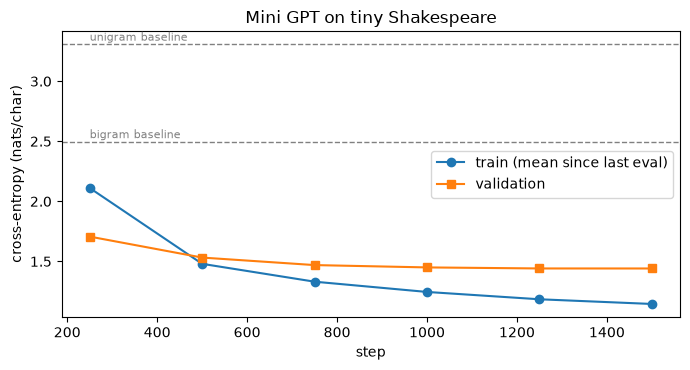

In [53]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(history["step"], history["train"], "o-", label="train (mean since last eval)")
ax.plot(history["step"], history["val"], "s-", label="validation")
for name, value in baselines.items():
    if name != "uniform":
        ax.axhline(value, linestyle="--", linewidth=1, color="gray")
        ax.text(history["step"][0], value + 0.03, f"{name} baseline", color="gray", fontsize=8)
ax.set(xlabel="step", ylabel="cross-entropy (nats/char)", title="Mini GPT on tiny Shakespeare")
ax.legend()
plt.tight_layout()
plt.show()

### Step 7 — Restore the best checkpoint and evaluate on test (once)

In [54]:
model.load_state_dict(best_state)
test_loss = evaluate(model, test_data)
test_bigram = -bigram_logp[test_data[:-1], test_data[1:]].mean().item()

print(f"test loss            : {test_loss:.3f} nats/char  = {test_loss / math.log(2):.2f} bits/char | perplexity {math.exp(test_loss):.2f}")
print(f"bigram on test       : {test_bigram:.3f} nats/char")
improvement = 1 - test_loss / test_bigram
print(f"→ the GPT's loss is {improvement:.0%} lower than the bigram baseline" if test_loss < test_bigram
      else "→ the GPT did not beat the bigram baseline — train longer or check the setup")


# Why can test loss differ from validation loss? The splits are different stretches of the corpus (different plays).
import re


def word_set(split_ids):
    return re.findall(r"[a-z']+", decode_chars(split_ids.tolist()).lower())


train_words = set(word_set(train_data))
oov = {name: np.mean([w not in train_words for w in word_set(split)]) for name, split in [("val", val_data), ("test", test_data)]}
print(f"\nwords never seen in training → validation {oov['val']:.1%} | test {oov['test']:.1%}")
if test_loss > best_val + 0.1 and oov["test"] > oov["val"]:
    print("→ the test text contains many more unseen words (new plays and character names), so a higher test loss "
          "is distribution shift — and exactly why we report the untouched test number, not the validation one.")

torch.save(best_state, OUTPUT_DIR / "mini_gpt_shakespeare.pt")
print("saved best weights to", OUTPUT_DIR / "mini_gpt_shakespeare.pt")

test loss            : 1.733 nats/char  = 2.50 bits/char | perplexity 5.66
bigram on test       : 2.503 nats/char
→ the GPT's loss is 31% lower than the bigram baseline

words never seen in training → validation 5.6% | test 10.0%
→ the test text contains many more unseen words (new plays and character names), so a higher test loss is distribution shift — and exactly why we report the untouched test number, not the validation one.
saved best weights to _outputs/mini_gpt_shakespeare.pt


### Step 8 — Generate Shakespeare (with the KV cache)

In [55]:
prompt_ids = torch.tensor([encode_chars("ROMEO:\n")], device=DEVICE)
n_generate = cfg.block_size - prompt_ids.size(1)
generate(model, prompt_ids, 4, temperature=0.8, top_k=40, top_p=0.95)          # warm-up so timings exclude kernel setup

torch.manual_seed(7)
for label, kwargs in [("greedy", dict(temperature=0.0)),
                      ("temperature 0.8, top-k 40", dict(temperature=0.8, top_k=40)),
                      ("temperature 1.2, top-p 0.95", dict(temperature=1.2, top_p=0.95))]:
    sync()
    start = time.perf_counter()
    sample_ids = generate(model, prompt_ids, n_generate, use_cache=True, **kwargs)
    sync()
    elapsed = time.perf_counter() - start
    print(f"━━━ {label} ({n_generate / elapsed:,.0f} tokens/sec) ━━━")
    print(decode_chars(sample_ids[0].tolist()))
    print()

━━━ greedy (138 tokens/sec) ━━━
ROMEO:
And then I say, the man is not to me.

KING RICHARD III:
The king is not to the common country.

KING RICHARD III:
The king is not to the court of this seat,
And then the sea that thou shalt not speak.

KING RICHARD III:
The king is not to the commo



━━━ temperature 0.8, top-k 40 (702 tokens/sec) ━━━
ROMEO:
And gracious lord, It is a hoteyess said;
And since I seem to live, or game to tear
In that is my king, not repair and royal young.

BENVOLIO:
Faith, became to the same, let's lose you think.

Nurse:
I know you must do you good will not be pilgrimen



━━━ temperature 1.2, top-p 0.95 (632 tokens/sec) ━━━
ROMEO:
But no tongueless, he must be, I must
Not too: you'll kind me: for you know.

EDWARD:
That, canst thou go?

GLOUCESTER:
A night: let me learn of sufferant friend,
I warrant you, the fault climate mine;
For I by Bolingbroke the betwixt York,
Which is



**Stretch goals**
1. Train on **BPE tokens** from Section 3 instead of characters (compare *bits per character*, not loss per token — tokens cover different amounts of text).
2. Scale up (`d_model=384, n_layers=6`) and train longer. How do validation loss and tokens/sec change?
3. Replace LayerNorm with **RMSNorm** (`nn.RMSNorm`) and the GELU MLP with **SwiGLU** (Llama-style), keeping the parameter count similar.
4. Implement **grouped-query attention** (fewer KV heads) in `CausalSelfAttention` and measure the KV-cache size.
5. Make generation go beyond `block_size` with a **rolling KV cache** that drops the oldest entries (how sliding-window models decode).

### 🗣️ How to talk about this in an interview
- "I implemented a decoder-only transformer from scratch in PyTorch — multi-head causal attention with RoPE, pre-LN blocks, weight tying and a KV cache — and verified my attention against `F.scaled_dot_product_attention` and `nn.MultiheadAttention` with `allclose`."
- "I split the corpus contiguously 80/10/10, selected the checkpoint on validation, and reported test loss once, alongside unigram and bigram baselines."
- "My first sanity check was the initial loss ≈ ln(vocab); I also ran a causality test that perturbs future tokens, which catches mask and reshape bugs."
- "The KV cache produced the same greedy tokens as full recomputation, and I measured how its speed-up grows with sequence length; I can derive its memory as 2·L·n_kv_heads·d_head·T·batch·bytes."
- "Next I'd move to BPE tokens, GQA, and RMSNorm/SwiGLU to match modern Llama-style architectures."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Walk me through self-attention step by step.**

<details><summary>Show answer</summary>

- **30-second answer:** Each token vector is projected by three learned matrices into a query, key, and value. Every query is dot-producted with every key, the scores are divided by √d_k, masked if needed, and softmaxed row-wise into weights that sum to 1. Each output is the weighted sum of the values, followed by an output projection: `softmax(QKᵀ/√d_k + mask) V`.
- **Go deeper:** Shapes: `(B, T, C)` → split heads `(B, h, T, d_head)` → scores `(B, h, T, T)` → outputs `(B, h, T, d_head)` → merge `(B, T, C)` → `W_o`. Q and K decide *where* to look, V decides *what* is copied. Time O(T²·d).
- **❌ Common wrong answer:** "The attention weights are learned parameters." Only the projections are learned; the weights are recomputed for every input.

</details>

**Q2. Why do we divide by √d_k?**

<details><summary>Show answer</summary>

- **30-second answer:** If query and key components have unit variance, their dot product has variance d_k. Large-magnitude scores saturate softmax (nearly one-hot), where gradients are almost zero. Dividing by √d_k keeps the scores' variance around 1, so training stays stable.
- **Go deeper:** In this notebook at d_k = 1024 the unscaled softmax put almost all weight on one key and its gradient was many times smaller than the scaled version. `F.scaled_dot_product_attention` exposes a `scale=` argument; some models add QK-normalization for extra stability.
- **❌ Common wrong answer:** "So the weights sum to 1" (that's softmax's job) or "divide by d_k" (the standard deviation is √d_k).

</details>

**Q3. Why use multiple attention heads?**

<details><summary>Show answer</summary>

- **30-second answer:** Each head attends in its own lower-dimensional subspace, so one layer can capture several relationships at once — e.g. the previous token, the syntactic head, a coreferent noun — instead of averaging them into one distribution. Since `d_head = d_model / h`, the cost is similar to one wide head.
- **Go deeper:** The parameter count (4·d²) doesn't depend on h. Many heads turn out redundant and can be pruned. **MQA** shares one K/V head across all query heads and **GQA** shares K/V within groups, cutting KV-cache memory with little quality loss.
- **❌ Common wrong answer:** "More heads = more parameters = more capacity."

</details>

**Q4. What is causal masking, and how can a decoder train on all positions in parallel?**

<details><summary>Show answer</summary>

- **30-second answer:** The causal mask sets scores for future positions to −∞ before softmax, so token t only attends to tokens ≤ t. That lets one forward pass produce a prediction at every position, with targets equal to the inputs shifted by one (teacher forcing) — no position sees its own answer.
- **Go deeper:** Implement with `tril`; `is_causal=True` in SDPA. Padding masks are combined with AND. With a KV cache and a single new query no mask is needed — and `is_causal=True` is top-left aligned, which is wrong when query and key lengths differ.
- **❌ Common wrong answer:** "The mask is only needed at inference." At inference the future doesn't exist yet; the mask matters in training.

</details>

**Q5. Compare sinusoidal/learned positional encodings with RoPE.**

<details><summary>Show answer</summary>

- **30-second answer:** Attention is permutation-equivariant, so order must be injected. The original Transformer adds fixed sinusoids to the input embeddings (GPT-2 and BERT learn a position table). RoPE rotates queries and keys by a position-dependent angle in every layer, so `q·k` depends only on the relative offset; it has no parameters and is used by Llama, Mistral and Qwen.
- **Go deeper:** Values aren't rotated. Learned absolute tables can't go beyond the trained length; RoPE contexts are commonly extended by rescaling frequencies (position interpolation, NTK-aware scaling, YaRN). ALiBi is another relative scheme that adds a distance penalty to scores.
- **❌ Common wrong answer:** "RoPE is added to the embeddings like sinusoids" or "transformers know order because they read left to right."

</details>

**Q6. LayerNorm vs BatchNorm — and pre-LN vs post-LN?**

<details><summary>Show answer</summary>

- **30-second answer:** BatchNorm normalizes each feature across the batch, so outputs depend on other examples and it needs running statistics — bad for variable-length text and batch-size-1 generation. LayerNorm normalizes each token across its features, identical in training and inference. Pre-LN (`x + f(LN(x))`, GPT-2 onward) keeps an un-normalized residual path, giving well-behaved gradients in deep stacks and less need for warm-up; post-LN (`LN(x + f(x))`, original Transformer and BERT) is harder to train deep.
- **Go deeper:** Pre-LN needs a final LayerNorm before the output head. Llama-style models use RMSNorm (no mean subtraction, no bias). Xiong et al. (2020) analyze why post-LN needs warm-up.
- **❌ Common wrong answer:** "LayerNorm normalizes over the sequence/time dimension."

</details>

**Q7. Why are residual connections essential in transformers?**

<details><summary>Show answer</summary>

- **30-second answer:** `x + f(x)` gives gradients an identity path straight to early layers, so dozens of layers train; each block only learns an update to a shared "residual stream". In this notebook a 24-block stack without residuals delivered far less gradient to its input.
- **Go deeper:** GPT-2 scales residual-branch output projections at init by 1/√(number of residual layers) so the stream's variance doesn't grow with depth. Interpretability work treats the residual stream as a communication channel that attention and MLP layers read from and write to.
- **❌ Common wrong answer:** "They reduce the number of parameters" or "they prevent overfitting."

</details>

**Q8. Encoder-only vs decoder-only vs encoder–decoder — which models use which?**

<details><summary>Show answer</summary>

- **30-second answer:** Encoder-only (BERT, RoBERTa) uses bidirectional attention — strong for classification and embeddings, not for free generation. Decoder-only (GPT family, Llama, Mistral, Qwen) uses causal attention and next-token prediction — the standard LLM design. Encoder–decoder (original Transformer, T5, BART, Whisper) encodes the input bidirectionally and a causal decoder cross-attends to it — translation, summarization, speech-to-text.
- **Go deeper:** In cross-attention, queries come from the decoder and keys/values from the encoder output. Decoder-only dominates because a single objective works on raw text at scale and pairs naturally with KV caching.
- **❌ Common wrong answer:** "BERT generates text like GPT" or "GPT is an encoder."

</details>

**Q9. How do temperature, top-k, and top-p change generation?**

<details><summary>Show answer</summary>

- **30-second answer:** Temperature divides logits before softmax: below 1 sharpens the distribution, above 1 flattens it, and → 0 becomes greedy. Top-k keeps only the k most likely tokens; top-p keeps the smallest set whose cumulative probability reaches p, so the number of candidates adapts to the model's confidence. Then renormalize and sample.
- **Go deeper:** Pure greedy/beam search tends to produce repetitive, bland text (Holtzman et al., "The Curious Case of Neural Text Degeneration"). Use temperature 0 for extraction/classification; ~0.7 with top-p 0.9–0.95 for creative text. Even temperature 0 isn't perfectly reproducible on GPUs because of batching and floating-point nondeterminism.
- **❌ Common wrong answer:** "Top-p 0.9 keeps the top 90% of the vocabulary" or "temperature changes the model's weights."

</details>

### 💻 Coding

**Q10. Implement causal multi-head self-attention in PyTorch.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  B, T, C = x.shape
  q, k, v = qkv(x).split(C, dim=-1)
  q, k, v = (t.view(B, T, h, C // h).transpose(1, 2) for t in (q, k, v))
  scores = q @ k.transpose(-2, -1) / math.sqrt(C // h)
  scores = scores.masked_fill(~torch.ones(T, T, dtype=torch.bool, device=x.device).tril(), float("-inf"))
  y = (scores.softmax(-1) @ v).transpose(1, 2).reshape(B, T, C)
  return proj(y)
  ```
- **Go deeper:** Verify with `torch.allclose(y, F.scaled_dot_product_attention(q, k, v, is_causal=True)...)` and a causality test (perturb token t, outputs before t must not change). In production use SDPA so PyTorch can pick FlashAttention/memory-efficient kernels.
- **❌ Common wrong answer:** Splitting with `view(B, h, T, d)` or merging without `transpose(1, 2)` — shapes look right but positions get scrambled.

</details>

**Q11. Derive the KV-cache memory. How big is it for Llama-3-8B at 8k tokens?**

<details><summary>Show answer</summary>

- **30-second answer:** `bytes = 2 × n_layers × n_kv_heads × d_head × seq_len × batch × bytes_per_value`. Llama-3-8B has 32 layers, 8 KV heads (GQA), d_head 128: `2·32·8·128·8192·1·2 ≈ 1.0 GiB` per sequence in fp16. With full multi-head attention (32 KV heads) it would be 4 GiB.
- **Go deeper:** The cache turns each decoding step from reprocessing T tokens into processing 1, but decoding is then limited by memory bandwidth, not compute. Reduce it with GQA/MQA, KV-cache quantization (8/4-bit), sliding windows, and PagedAttention (vLLM) to avoid fragmentation and share prefixes.
- **❌ Common wrong answer:** "It caches Q, K and V" (past queries are never reused) or forgetting the factor of 2 or the layer count.

</details>

### 🐛 Debugging Scenarios

**Q12. Training loss drops close to 0 within a few hundred steps, but generated text is garbage. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** The model can see the answer — targets not shifted by one, a broken causal mask (e.g. `nn.MultiheadAttention`'s inverted boolean convention), or a head reshape bug that mixes positions. It learns to copy rather than predict.
- **Go deeper:** Cheap sanity checks: initial loss ≈ ln(vocab); a causality test that perturbs future tokens; compare with a bigram baseline — a small character model on Shakespeare lands well above 1 nat/char, so a near-zero loss is a red flag.
- **❌ Common wrong answer:** "The model converged — great, lower the learning rate."

</details>

**Q13. The loss becomes `nan` only on batches that contain padding. How do you debug it?**

<details><summary>Show answer</summary>

- **30-second answer:** A query row whose keys are all masked gets softmax over all −∞, which is `nan`, and it spreads through the network. Make sure every row has at least one allowed key or zero out those rows, and exclude padding positions from the loss (`ignore_index`).
- **Go deeper:** In fp16, "large negative" constants like −1e9 overflow — use `torch.finfo(dtype).min` or boolean masks. Different SDPA backends handle fully masked rows differently, so don't rely on one. Locate the first `nan` with forward hooks or `torch.autograd.set_detect_anomaly(True)`.
- **❌ Common wrong answer:** "Lower the learning rate or add gradient clipping."

</details>

### 🏗️ Design

**Q14. Attention is O(n²). How do models handle 100k+ token contexts?**

<details><summary>Show answer</summary>

- **30-second answer:** Several complementary tricks. **FlashAttention** computes exact attention in GPU-memory-friendly blocks without materializing the n×n matrix — memory becomes O(n) and it's faster, though compute is still O(n²). **Sliding-window attention** (Mistral 7B; Longformer adds global tokens) limits each token to the last w tokens → O(n·w). **GQA/MQA** shrink the KV cache so long sequences fit during decoding. Plus RoPE frequency scaling to extend context, paged/quantized KV caches, and sequence/context parallelism for training.
- **Go deeper:** Prefill (processing the prompt) is compute-bound and quadratic; decode is memory-bandwidth-bound and linear per step, dominated by KV-cache reads. Alternatives such as linear attention and state-space models (Mamba) trade exact attention for linear cost; many recent models mix them with some full-attention layers.
- **❌ Common wrong answer:** "FlashAttention approximates attention" or "FlashAttention makes attention linear-time."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `q` has shape `(2, 8, 10, 64)` and `k` has shape `(2, 8, 15, 64)`. What is the shape of `q @ k.transpose(-2, -1)`?
<details><summary>Answer</summary>

`(2, 8, 10, 15)` — one score per (batch, head, query, key).
</details>

**2.** `torch.softmax(torch.tensor([0., float('-inf'), 1.]), dim=0)`
<details><summary>Answer</summary>

`tensor([0.2689, 0.0000, 0.7311])` — `-inf` becomes exactly 0; the rest renormalize.
</details>

**3.** How many parameters does `nn.Linear(512, 2048)` have?
<details><summary>Answer</summary>

`1,050,624` = 512 × 2048 weights + 2048 biases.
</details>

**4.** `torch.ones(4, 4).tril().sum()`
<details><summary>Answer</summary>

`tensor(10.)` — a causal mask of size T has T(T+1)/2 allowed pairs.
</details>

**5.** A model with 2 layers, 2 KV heads and `d_head = 4` caches 10 tokens for 1 sequence in float32. How many bytes is the KV cache?
<details><summary>Answer</summary>

`1280` = 2 (K and V) × 2 layers × 2 heads × 4 × 10 tokens × 1 × 4 bytes.
</details>

## 📚 Resources

### 📖 Official Docs
- [torch.nn.functional.scaled_dot_product_attention — PyTorch 2.14 documentation](https://docs.pytorch.org/docs/2.14/generated/torch.nn.functional.scaled_dot_product_attention.html) — mask conventions, `is_causal`, `enable_gqa`, and the reference implementation
- [(Beta) Implementing High-Performance Transformers with Scaled Dot Product Attention (SDPA)](https://docs.pytorch.org/tutorials/intermediate/scaled_dot_product_attention_tutorial.html) — official tutorial on the fused kernels
- [MultiheadAttention — PyTorch 2.14 documentation](https://docs.pytorch.org/docs/2.14/generated/torch.nn.MultiheadAttention.html) — note its inverted boolean mask
- [Hugging Face LLM Course — Byte-Pair Encoding tokenization](https://huggingface.co/learn/llm-course/chapter6/5) — BPE as used by real tokenizers
- [Hugging Face — Generation strategies](https://huggingface.co/docs/transformers/main/en/generation_strategies) — greedy, sampling, top-k/top-p, and more in practice

### 🎥 Videos
- [Andrej Karpathy — Let's build GPT: from scratch, in code, spelled out.](https://www.youtube.com/watch?v=kCc8FmEb1nY) (1 h 56 min) — builds a character-level GPT on tiny Shakespeare line by line; the perfect companion to the mini project
- [3Blue1Brown — Attention in transformers, step-by-step | Deep Learning Chapter 6](https://www.youtube.com/watch?v=eMlx5fFNoYc) (26 min) — the clearest visual intuition for queries, keys, values, and multiple heads
- [Andrej Karpathy — Let's build the GPT Tokenizer](https://www.youtube.com/watch?v=zduSFxRajkE) (2 h 13 min) — byte-level BPE from scratch and why tokenization causes many LLM quirks

### 📄 Papers
- [Vaswani et al. (2017) — Attention Is All You Need](https://arxiv.org/abs/1706.03762) — the original Transformer
- [Su et al. (2021) — RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864) — RoPE
- [Sennrich et al. (2016) — Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909) — BPE for NLP
- [Xiong et al. (2020) — On Layer Normalization in the Transformer Architecture](https://arxiv.org/abs/2002.04745) — why pre-LN trains more easily
- [Dao et al. (2022) — FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness](https://arxiv.org/abs/2205.14135)
- [Shazeer (2019) — Fast Transformer Decoding: One Write-Head is All You Need](https://arxiv.org/abs/1911.02150) — multi-query attention
- [Ainslie et al. (2023) — GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245)
- [Holtzman et al. (2019) — The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751) — nucleus (top-p) sampling
- [Kwon et al. (2023) — Efficient Memory Management for Large Language Model Serving with PagedAttention](https://arxiv.org/abs/2309.06180) — vLLM's KV-cache paging

### 📘 Books & Courses
- [Jay Alammar — The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — the classic visual walkthrough
- [Harvard NLP — The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — the original paper as runnable PyTorch code
- [Dive into Deep Learning — Chapter 11: Attention Mechanisms and Transformers](https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html) — free textbook chapter with math and code
- [karpathy/nanoGPT](https://github.com/karpathy/nanoGPT) — a compact, fast GPT training repository to study next

### 🏋️ Practice
- [karpathy/minbpe — exercise.md](https://github.com/karpathy/minbpe/blob/master/exercise.md) — build a GPT-4-style tokenizer step by step
- [Deep-ML — Practice Problems](https://www.deep-ml.com/problems) — implement attention, layer norm, and other ML building blocks with instant feedback

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Tokenization | text → ids | characters; byte-level **BPE**: merge most frequent pair repeatedly |
| Embedding | id → vector | `nn.Embedding(V, d)`; tie with output head |
| Attention | tokens read from each other | `softmax(QKᵀ/√d_k + mask) V` · `F.scaled_dot_product_attention` |
| √d_k | keeps scores' variance ≈ 1 | avoids softmax saturation → vanishing gradients |
| Masks | forbid future / padding | `tril`; `True = attend` in SDPA, `True = block` in `nn.MultiheadAttention` |
| Multi-head | parallel subspaces | `(B,T,C)` → `view(B,T,h,d).transpose(1,2)` → merge with `transpose(1,2).reshape` |
| Positions | inject order | sinusoidal/learned (added once) · **RoPE** (rotate q, k each layer → relative) |
| Block | refine tokens | pre-LN: `x + Attn(LN(x))`, `x + MLP(LN(x))`; GELU MLP 4× |
| Families | model types | encoder (BERT) · decoder (GPT, Llama) · encoder–decoder (T5, Whisper) |
| Parameters | model size | `≈ 12·L·d² + V·d` |
| Cost | scaling | attention O(T²) time/memory; MLP O(T); FlashAttention → O(T) memory |
| Sampling | choose next token | greedy · `logits/τ` · top-k · top-p (nucleus) |
| KV cache | fast decoding | `2·L·n_kv_heads·d_head·T·batch·bytes`; GQA/MQA/PagedAttention shrink it |

## ➡️ What's Next

**[04 · Keras 3 Overview](04_Keras_3_Overview.ipynb)** *(optional)* — see the same deep-learning ideas through Keras's high-level, multi-backend API.

**[05 NLP · Classical NLP](../05_NLP/01_Classical_NLP.ipynb)** — step back to the classic text-processing toolkit (tokenization, TF-IDF, word vectors) that still powers search and baselines, before moving on to embeddings and Hugging Face transformers.